# 1 — IMPORTS

In [45]:
import warnings
warnings.filterwarnings("ignore")

import os
import re
import html
import string
import random

from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import nltk

from nltk.corpus import stopwords
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import f_classif

from wordcloud import WordCloud

# Optional
try:
    import emoji
except:
    emoji = None

# 2 — CONFIG

In [46]:
FILE_PATH = "train.csv"
TEXT_COL = "text"
LABEL_COL = "status"

CLASS_NAMES = ["Normal","Depression","Suicidal","Anxiety"]
COLORS = ["#4C72B0","#DD8452","#55A868","#C44E52"]

RANDOM_STATE = 42

# reproducibility
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

MAX_FEATURES_TFIDF = 10000
NGRAMS_TFIDF = (1, 2)

MIN_DF = 3
MAX_DF = 0.95

TOP_N = 20
MIN_WORD_LENGTH = 2
STOPWORDS_LANG = "english"

#Chuẩn hóa regex token filtering cho preprocessing/text cleaning
TOKEN_PATTERN = r"\b[a-zA-Z]+\b"

SHORT_TEXT_THRESHOLD = 3
FIG_DIR = "figures"
DPI = 150

# Kiểm soát việc lưu hình và hiển thị visualization linh hoạt hơn
SAVE_FIGURES = True
SHOW_FIGURES = True

# Hiển thị dataframe đẹp hơn, dễ debug và xem text dài đầy đủ hơn
pd.set_option("display.max_colwidth", 300)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Đồng bộ style, kích thước và chất lượng visualization cho toàn notebook
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = DPI

# 3 — NLTK SETUP

In [47]:
# Kiểm tra và tải tài nguyên NLTK
for resource in ['punkt', 'stopwords', 'punkt_tab']:

    try:
        nltk.data.find(
            f"tokenizers/{resource}"
            if resource in ['punkt', 'punkt_tab']
            else f"corpora/{resource}"
        )

    except LookupError:
        nltk.download(resource)
stop_words = set(stopwords.words(STOPWORDS_LANG))

if FIG_DIR and not os.path.exists(FIG_DIR):
    os.makedirs(FIG_DIR)

# 4 — LOAD DATA

In [48]:
def load_data(path):
    df = pd.read_csv(path)
    print("=" * 60)
    print("DATASET LOADED")
    print("=" * 60)
    print(f"Shape: {df.shape}")
    return df
df = load_data(FILE_PATH)

DATASET LOADED
Shape: (35422, 2)


## 5 — BASIC DATASET INFO 

In [49]:
def basic_info(df):

    print("=" * 60)
    print("1. DATASET SUMMARY")
    print("=" * 60)
    
    df = df.copy()

    total_samples = len(df)
    num_classes = df[LABEL_COL].nunique()
    missing_text = df[TEXT_COL].isna().sum()
    missing_label = df[LABEL_COL].isna().sum()
    empty_text = (df[TEXT_COL].astype(str).str.strip().eq("").sum())
    dup_rows = df.duplicated().sum()
    dup_texts = df.duplicated(subset=[TEXT_COL]).sum()

    df["word_count"] = (df[TEXT_COL].astype(str).apply(lambda x: len(x.split())))
    mean_wc = df["word_count"].mean()
    median_wc = df["word_count"].median()

    df["char_count"] = (
        df[TEXT_COL]
        .astype(str)
        .apply(len)
    )

    mean_char = df["char_count"].mean()
    median_char = df["char_count"].median()

    all_words_raw = set()
    for text in df[TEXT_COL].astype(str):
        tokens = word_tokenize(text.lower())
        all_words_raw.update([word for word in tokens if word.isalnum()])
    unique_words_raw = len(all_words_raw)

    # Class imbalance
    counts = df[LABEL_COL].value_counts()
    imb_ratio = (
        counts.max() / counts.min()
        if counts.min() > 0
        else float("inf")
    )
    # Memory usage
    memory_usage = (
        df.memory_usage(deep=True).sum()
        / 1024**2
    )

    # Summary table
    summary_table = pd.DataFrame({
        "Property": [
            "Total Samples",
            "Number of Classes",
            "Missing Values (Text)",
            "Missing Values (Label)",
            "Empty Texts",
            "Exact Duplicate Rows",
            "Duplicate Texts",
            "Unique Words (raw)",
            "Mean Word Count",
            "Median Word Count",
            "Mean Character Count",
            "Median Character Count",
            "Imbalance Ratio (max/min)",
            "Dataset Memory Usage (MB)"
        ],

        "Value": [
            total_samples,
            num_classes,
            missing_text,
            missing_label,
            empty_text,
            dup_rows,
            dup_texts,
            f"{unique_words_raw:,}",
            f"{mean_wc:.2f}",
            f"{median_wc:.2f}",
            f"{mean_char:.2f}",
            f"{median_char:.2f}",
            f"{imb_ratio:.2f}",
            f"{memory_usage:.2f} MB"
        ]
    })

    print(summary_table.to_string(index=False))
    print("\n")
    return df
df = basic_info(df)

1. DATASET SUMMARY
                 Property    Value
            Total Samples    35422
        Number of Classes        4
    Missing Values (Text)        0
   Missing Values (Label)        0
              Empty Texts        0
     Exact Duplicate Rows      598
          Duplicate Texts      603
       Unique Words (raw)   41,099
          Mean Word Count    79.08
        Median Word Count    48.00
     Mean Character Count   404.01
   Median Character Count   247.00
Imbalance Ratio (max/min)     3.24
Dataset Memory Usage (MB) 22.49 MB




## 6 — CLASS DISTRIBUTION


2. CLASS DISTRIBUTION
normal      : 13,047 ( 36.8%)
depression  : 10,327 ( 29.2%)
suicidal    :  8,022 ( 22.6%)
anxiety     :  4,026 ( 11.4%)

Tỷ lệ mất cân bằng:
Max / Min = 3.24:1


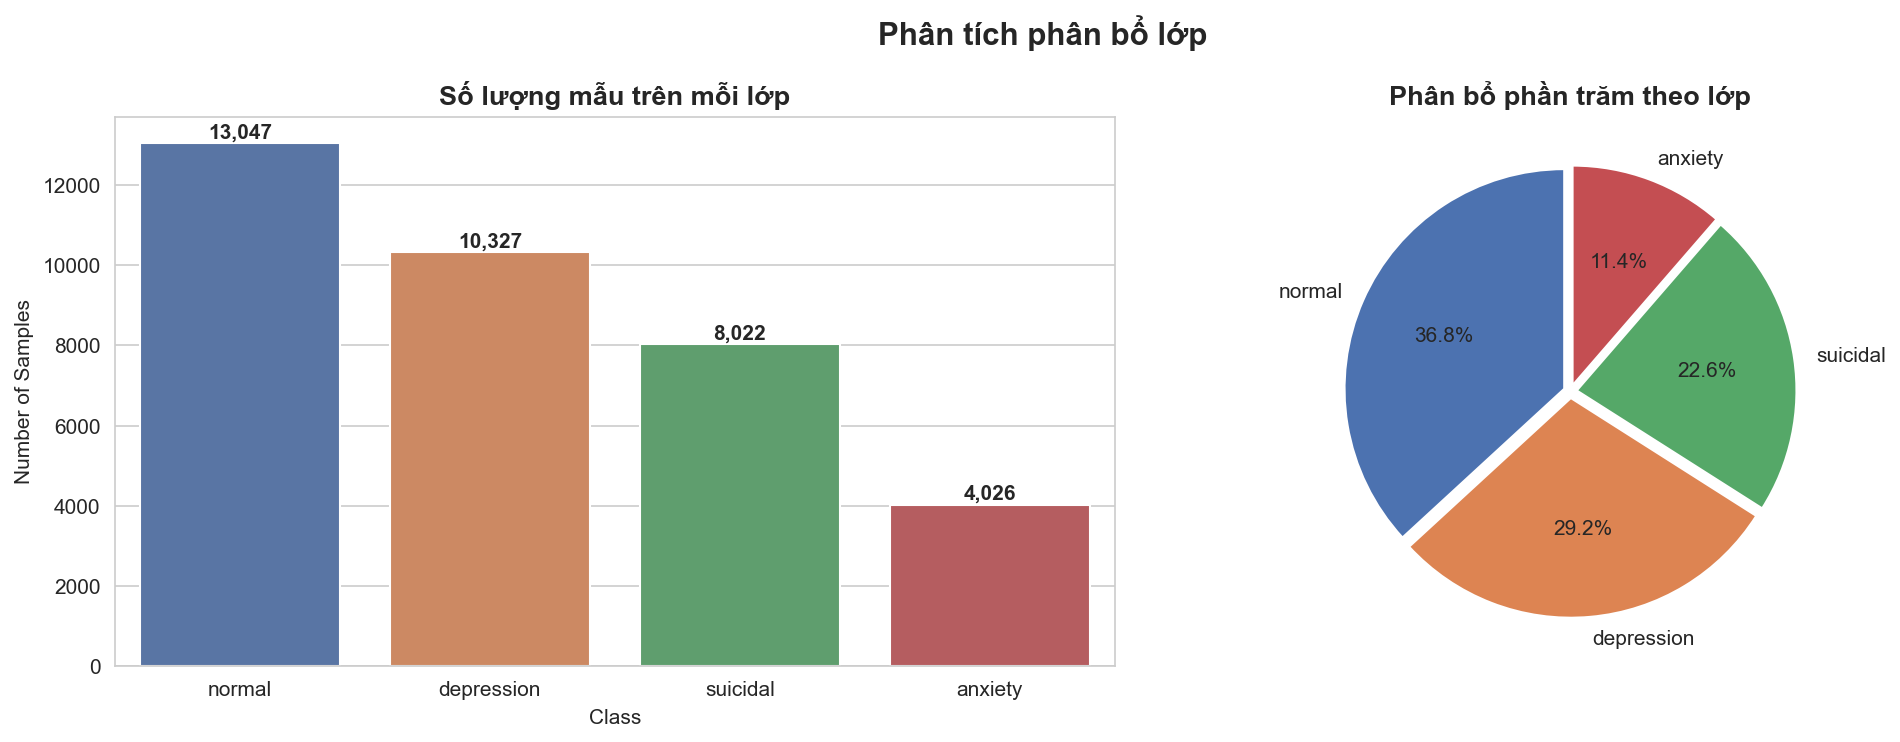

In [50]:
# Normalize labels trước khi EDA
df[LABEL_COL] = (df[LABEL_COL]
    .astype(str)      # Ép về string
    .str.strip()      # Xóa khoảng trắng thừa
    .str.lower()      # Chuyển về lowercase
)

# Class names chuẩn hóa
CLASS_NAMES = ["normal", "depression", "suicidal", "anxiety"]

# CLASS DISTRIBUTION FUNCTION
def class_distribution(df):
    print("\n" + "=" * 60)
    print("2. CLASS DISTRIBUTION")
    print("=" * 60)
    counts = (df[LABEL_COL].value_counts().reindex(CLASS_NAMES).fillna(0).astype(int))
    # Tổng số samples
    total = counts.sum()
    if total == 0:
        print("ERROR: Không tìm thấy class hợp lệ")
        print("\nLabels hiện có:")
        print(df[LABEL_COL].unique())
        return
    percents = (counts / total) * 100
    # In thống kê
    for cls in CLASS_NAMES:
        print( f"{cls:<12}: " f"{counts[cls]:>6,} " f"({percents[cls]:5.1f}%)")
    non_zero_counts = counts[counts > 0]
    imb_ratio = (non_zero_counts.max()/ non_zero_counts.min()
    )

    print("\nTỷ lệ mất cân bằng:")
    print(f"Max / Min = {imb_ratio:.2f}:1")
    fig, axes = plt.subplots(1,2,figsize=(14, 5))
    sns.barplot(x=counts.index,y=counts.values,palette=COLORS,ax=axes[0])
    axes[0].set_title("Số lượng mẫu trên mỗi lớp",fontsize=13,fontweight="bold")
    axes[0].set_xlabel("Class")
    axes[0].set_ylabel("Number of Samples")

    # Hiển thị số trên cột
    max_count = max(counts.values)
    for i, value in enumerate(counts.values):
        axes[0].text(
            i,
            value + max_count * 0.01,
            f"{value:,}",
            ha='center',
            fontsize=10,
            fontweight='bold'
        )

    pie_counts = counts[counts > 0]
    explode = [0.03] * len(pie_counts)
    axes[1].pie(
        pie_counts.values,
        labels=pie_counts.index,
        autopct='%1.1f%%',
        colors=COLORS[:len(pie_counts)],
        startangle=90,
        explode=explode
    )
    axes[1].set_title(
        "Phân bổ phần trăm theo lớp",
        fontsize=13,
        fontweight="bold"
    )

    plt.suptitle(
        "Phân tích phân bổ lớp",
        fontsize=15,
        fontweight="bold"
    )

    plt.tight_layout()
    if SAVE_FIGURES:plt.savefig(os.path.join(FIG_DIR,"class_distribution.png"),
            dpi=DPI,
            bbox_inches="tight"
        )

    if SHOW_FIGURES:
        plt.show()

    plt.close()
class_distribution(df)

## 7 — TEXT LENGTH ANALYSIS


3. Phân tích độ dài văn bản
            mean_char  std_char  min_char  median_char  max_char  mean_word  std_word  median_word  max_word
status                                                                                                      
anxiety         645.2     753.3        10        492.0     12512      122.4     141.2         93.0      2265
depression      535.7     515.2        10        436.0     20717      106.1     100.1         87.0      4038
normal          130.1     445.7        10         61.0     38785       24.7      84.1         12.0      6353
suicidal        558.9     691.9         8        401.0     14527      110.9     133.4         80.5      2825


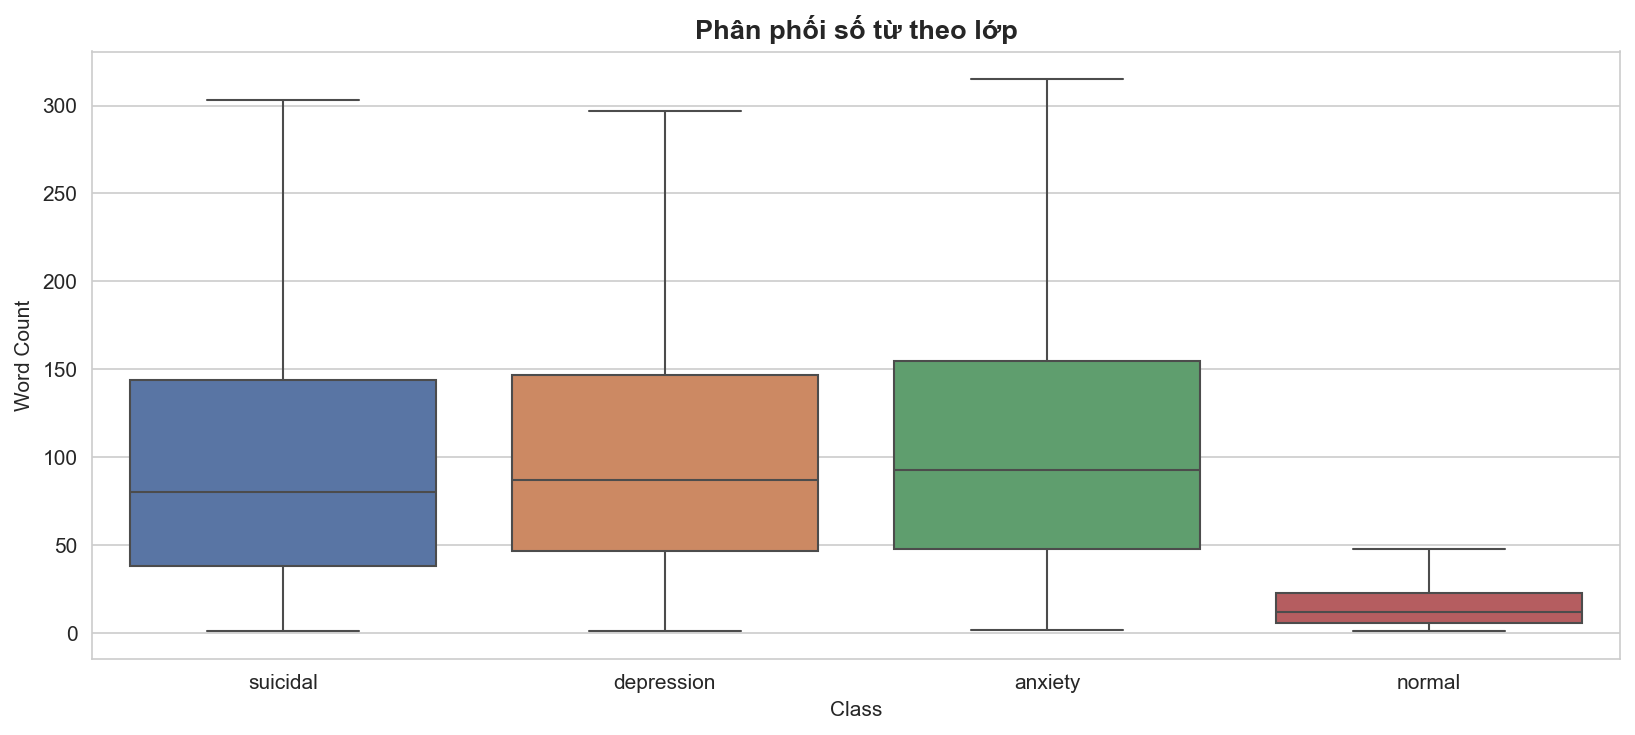


Phân vị số từ theo lớp:
normal      : P10=4 | P25=6 | P50=12 | P75=23 | P90=58 | P95=88 | P99=164
depression  : P10=24 | P25=47 | P50=87 | P75=147 | P90=202 | P95=229 | P99=392
suicidal    : P10=19 | P25=38 | P50=80 | P75=144 | P90=212 | P95=266 | P99=666
anxiety     : P10=18 | P25=48 | P50=93 | P75=155 | P90=217 | P95=307 | P99=623


In [51]:
def text_length_analysis(df):

    print("\n" + "=" * 60)
    print("3. Phân tích độ dài văn bản")
    print("=" * 60)
    df = df.copy()
    df['char_len'] = (
        df[TEXT_COL]
        .astype(str)
        .str.len()
    )

    if 'word_count' not in df.columns:

        df['word_count'] = (
            df[TEXT_COL]
            .astype(str)
            .apply(lambda x: len(x.split()))
        )
    # thống kê 
    length_stats = (
        df.groupby(LABEL_COL)
        .agg(
            mean_char=('char_len', 'mean'),
            std_char=('char_len', 'std'),
            min_char=('char_len', 'min'),
            median_char=('char_len', 'median'),
            max_char=('char_len', 'max'),
            mean_word=('word_count', 'mean'),
            std_word=('word_count', 'std'),
            median_word=('word_count', 'median'),
            max_word=('word_count', 'max')
        )
        .round(1)
    )
    print(length_stats)

    # boxplot
    fig, ax = plt.subplots(figsize=(11, 5))
    sns.boxplot(data=df, x=LABEL_COL, y='word_count', palette=COLORS, showfliers=False, ax=ax)
    ax.set_title( "Phân phối số từ theo lớp", fontsize=13,fontweight='bold')
    ax.set_xlabel("Class")
    ax.set_ylabel("Word Count")
    plt.tight_layout()

    if SAVE_FIGURES:
        plt.savefig(
            os.path.join(
                FIG_DIR,
                "word_count_boxplot.png"
            ),
            dpi=DPI,
            bbox_inches='tight'
        )

    if SHOW_FIGURES:
        plt.show()
    plt.close()

    print("\nPhân vị số từ theo lớp:")
    percentiles = [10, 25, 50, 75, 90, 95, 99]
    for cls in CLASS_NAMES:
        vals = df[df[LABEL_COL] == cls]['word_count']
        if len(vals) == 0:
            print(f"{cls}: Không có dữ liệu")
            continue
        perc_vals = np.percentile(
            vals,
            percentiles
        )
        result = " | ".join([
            f"P{p}={int(v)}"
            for p, v in zip(
                percentiles,
                perc_vals
            )
        ])

        print(f"{cls:<12}: {result}")

    return df
df_enriched = text_length_analysis(df)

## 8 — VOCABULARY ANALYSIS 

In [52]:
# Phân tích từ vựng nâng cao cho NLP EDA
def vocabulary_analysis(df):
    print("\n" + "=" * 60)
    print("\n 4. PHÂN TÍCH TỪ VỰNG")
    print("=" * 60)

    # Copy dataframe để tránh ảnh hưởng dữ liệu gốc
    df = df.copy()

    # Chuẩn hóa text tránh lỗi NaN
    df[TEXT_COL] = df[TEXT_COL].astype(str)

    # Hàm preprocess text dùng chung toàn bộ pipeline
    def preprocess_text(text):
        text = text.lower()  # Lowercase
        text = re.sub(r"http\S+|www\S+", " ", text) # Xóa URL
        text = re.sub(r"[^a-zA-Z\s]", " ", text)  # Xóa ký tự đặc biệt
        tokens = word_tokenize(text)  # Tokenize
        # Lọc token
        tokens = [
            token for token in tokens
            if (
                token not in stop_words
                and token.isalpha()
                and len(token) >= MIN_WORD_LENGTH
            )
        ]
        return tokens

    # Tokenize toàn bộ dataset chỉ 1 lần
    print("\nĐang tokenize dataset...")
    df["tokens"] = df[TEXT_COL].apply(preprocess_text)
    # Loại samples rỗng sau preprocess
    df = df[df["tokens"].str.len() > 0]
    print(f"Số samples còn lại: {len(df):,}")

    # Gom token theo class để tái sử dụng nhiều lần
    class_tokens = {}
    for cls in CLASS_NAMES:
        subset = df[df[LABEL_COL] == cls]
        all_tokens = []
        for tokens in subset["tokens"]:
            all_tokens.extend(tokens)
        class_tokens[cls] = all_tokens

    # 1. Top Unigrams
    print("\nVẽ top unigrams...")
    fig, axes = plt.subplots(len(CLASS_NAMES), 1, figsize=(11, 4 * len(CLASS_NAMES)))
    if len(CLASS_NAMES) == 1: axes = [axes]
    for ax, cls in zip(axes, CLASS_NAMES):
        counter = Counter(class_tokens[cls])
        top_words = counter.most_common(TOP_N)
        if len(top_words) == 0:
            ax.set_title(f"{cls} - No Data")
            continue
        words = [x[0] for x in top_words]
        counts = [x[1] for x in top_words]
        sns.barplot(x=counts, y=words, palette="viridis", ax=ax)
        ax.set_title(
            f"Top {TOP_N} Unigrams - {cls}",
            fontsize=12,
            fontweight="bold"
        )
        ax.set_xlabel("Frequency")
        ax.grid( axis='x', linestyle='--', alpha=0.5)

    plt.suptitle("Top Unigrams Theo Từng Class", fontsize=16, fontweight="bold")
    plt.tight_layout()
    if SAVE_FIGURES:
        plt.savefig(
            os.path.join(FIG_DIR, "top_unigrams.png"),
            dpi=DPI,
            bbox_inches="tight"
        )
    if SHOW_FIGURES:
        plt.show()
    plt.close()

    # 2. Top Bigrams
    print("\nVẽ top bigrams...")
    fig, axes = plt.subplots(len(CLASS_NAMES), 1, figsize=(11, 4 * len(CLASS_NAMES)))
    if len(CLASS_NAMES) == 1: axes = [axes]
    for ax, cls in zip(axes, CLASS_NAMES):
        bigram_counter = Counter()
        subset = df[df[LABEL_COL] == cls]
        for tokens in subset["tokens"]:
            bigrams_list = list(ngrams(tokens, 2))
            bigrams_list = [" ".join(bg) for bg in bigrams_list]
            bigram_counter.update(bigrams_list)
        top_bigrams = bigram_counter.most_common(TOP_N)

        if len(top_bigrams) == 0:
            ax.set_title(f"{cls} - No Data")
            continue

        bigram_words = [x[0] for x in top_bigrams]
        bigram_counts = [x[1] for x in top_bigrams]

        sns.barplot(x=bigram_counts, y=bigram_words, palette="magma", ax=ax)

        ax.set_title(f"Top {TOP_N} Bigrams - {cls}", fontsize=12, fontweight="bold")
        ax.set_xlabel("Frequency")
        ax.grid(axis='x', linestyle='--', alpha=0.5)

    plt.suptitle( "Top Bigrams Theo Từng Class", fontsize=16, fontweight="bold")

    plt.tight_layout()
    if SAVE_FIGURES:
        plt.savefig(
            os.path.join(FIG_DIR, "top_bigrams.png"),
            dpi=DPI,
            bbox_inches="tight"
        )
    if SHOW_FIGURES:
        plt.show()
    plt.close()

    # 3. Các thuật ngữ đặc trưng của TF-IDF
    print("\nĐang tính TF-IDF...")

    vectorizer = TfidfVectorizer(
        max_features=MAX_FEATURES_TFIDF,
        ngram_range=NGRAMS_TFIDF,
        stop_words="english",
        sublinear_tf=True,
        min_df=5,
        max_df=0.95
    )

    X_tfidf = vectorizer.fit_transform(df[TEXT_COL])
    feature_names = vectorizer.get_feature_names_out()
    fig, axes = plt.subplots(len(CLASS_NAMES), 1, figsize=(11, 4 * len(CLASS_NAMES)))
    if len(CLASS_NAMES) == 1: axes = [axes]
    for ax, cls in zip(axes, CLASS_NAMES):
        mask = (df[LABEL_COL] == cls).values
        if mask.sum() == 0:
            ax.set_title(f"{cls} - No Data")
            continue
        class_mean = X_tfidf[mask].mean(axis=0).A1
        top_indices = class_mean.argsort()[-TOP_N:][::-1]
        top_terms = [feature_names[i] for i in top_indices]
        top_scores = [class_mean[i] for i in top_indices]

        sns.barplot(x=top_scores, y=top_terms, palette="rocket",ax=ax)

        ax.set_title(f"Top TF-IDF Terms - {cls}", fontsize=12, fontweight="bold")
        ax.set_xlabel("Mean TF-IDF Score")
        ax.grid(axis='x', linestyle='--', alpha=0.5)

    plt.suptitle("TF-IDF Distinctive Terms", fontsize=16, fontweight="bold")
    plt.tight_layout()
    if SAVE_FIGURES:
        plt.savefig(
            os.path.join(FIG_DIR, "tfidf_terms.png"),
            dpi=DPI,
            bbox_inches="tight"
        )
    if SHOW_FIGURES:
        plt.show()
    plt.close()

    # 4. Sự trùng lặp từ vựng + Độ tương đồng Cosine
    vocab_sets = {}
    for cls in CLASS_NAMES:
        vocab_sets[cls] = set(class_tokens[cls])

    overlap_matrix = np.zeros((len(CLASS_NAMES), len(CLASS_NAMES)))
    for i, cls1 in enumerate(CLASS_NAMES):
        for j, cls2 in enumerate(CLASS_NAMES):
            intersection = len(vocab_sets[cls1].intersection(vocab_sets[cls2]))
            union = len(vocab_sets[cls1].union(vocab_sets[cls2]))
            overlap = (intersection / union * 100 if union > 0 else 0)
            overlap_matrix[i, j] = overlap

    # Độ tương đồng cosin
    centroids = []
    for cls in CLASS_NAMES:
        mask = (df[LABEL_COL] == cls).values
        if mask.sum() == 0:
            centroid = np.zeros(X_tfidf.shape[1])
        else:
            centroid = X_tfidf[mask].mean(axis=0).A1
        centroids.append(centroid)
    similarity_matrix = cosine_similarity(centroids)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    sns.heatmap(overlap_matrix, annot=True, fmt=".1f", cmap="YlOrRd", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
    axes[0].set_title("Vocabulary Overlap (%)", fontsize=13, fontweight="bold")
    sns.heatmap(similarity_matrix, annot=True, fmt=".3f", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,ax=axes[1])
    axes[1].set_title("TF-IDF Cosine Similarity", fontsize=13, fontweight="bold")

    plt.tight_layout()

    if SAVE_FIGURES:
        plt.savefig(
            os.path.join(FIG_DIR, "vocabulary_similarity.png"),
            dpi=DPI,
            bbox_inches="tight"
        )
    if SHOW_FIGURES:
        plt.show()
    plt.close()

    # 5.Loại Tỷ lệ Token (TTR)
    ttr_results = []
    for cls in CLASS_NAMES:
        subset = df[df[LABEL_COL] == cls]
        ttr_scores = subset["tokens"].apply(
            lambda x: (
                len(set(x)) / len(x)
                if len(x) > 0 else 0
            )
        )
        root_ttr_scores = subset["tokens"].apply(
            lambda x: (
                len(set(x)) / np.sqrt(len(x))
                if len(x) > 0 else 0
            )
        )
        ttr_results.append({
            "Class": cls,
            "Mean TTR": ttr_scores.mean(),
            "Median TTR": ttr_scores.median(),
            "Root TTR": root_ttr_scores.mean()
        })
    ttr_df = pd.DataFrame(ttr_results)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=ttr_df.melt(id_vars="Class", var_name="Metric", value_name="Score"), x="Class", y="Score", hue="Metric")
    plt.title("Lexical Diversity Analysis", fontsize=14, fontweight="bold")
    plt.ylabel("Score")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    if SAVE_FIGURES:plt.savefig(os.path.join(FIG_DIR, "lexical_diversity.png"),
            dpi=DPI, bbox_inches="tight"
        )
    if SHOW_FIGURES:
        plt.show()
    plt.close()
    print("\nHoàn tất vocabulary analysis.")
    return df



 4. PHÂN TÍCH TỪ VỰNG

Đang tokenize dataset...
Số samples còn lại: 35,351

Vẽ top unigrams...


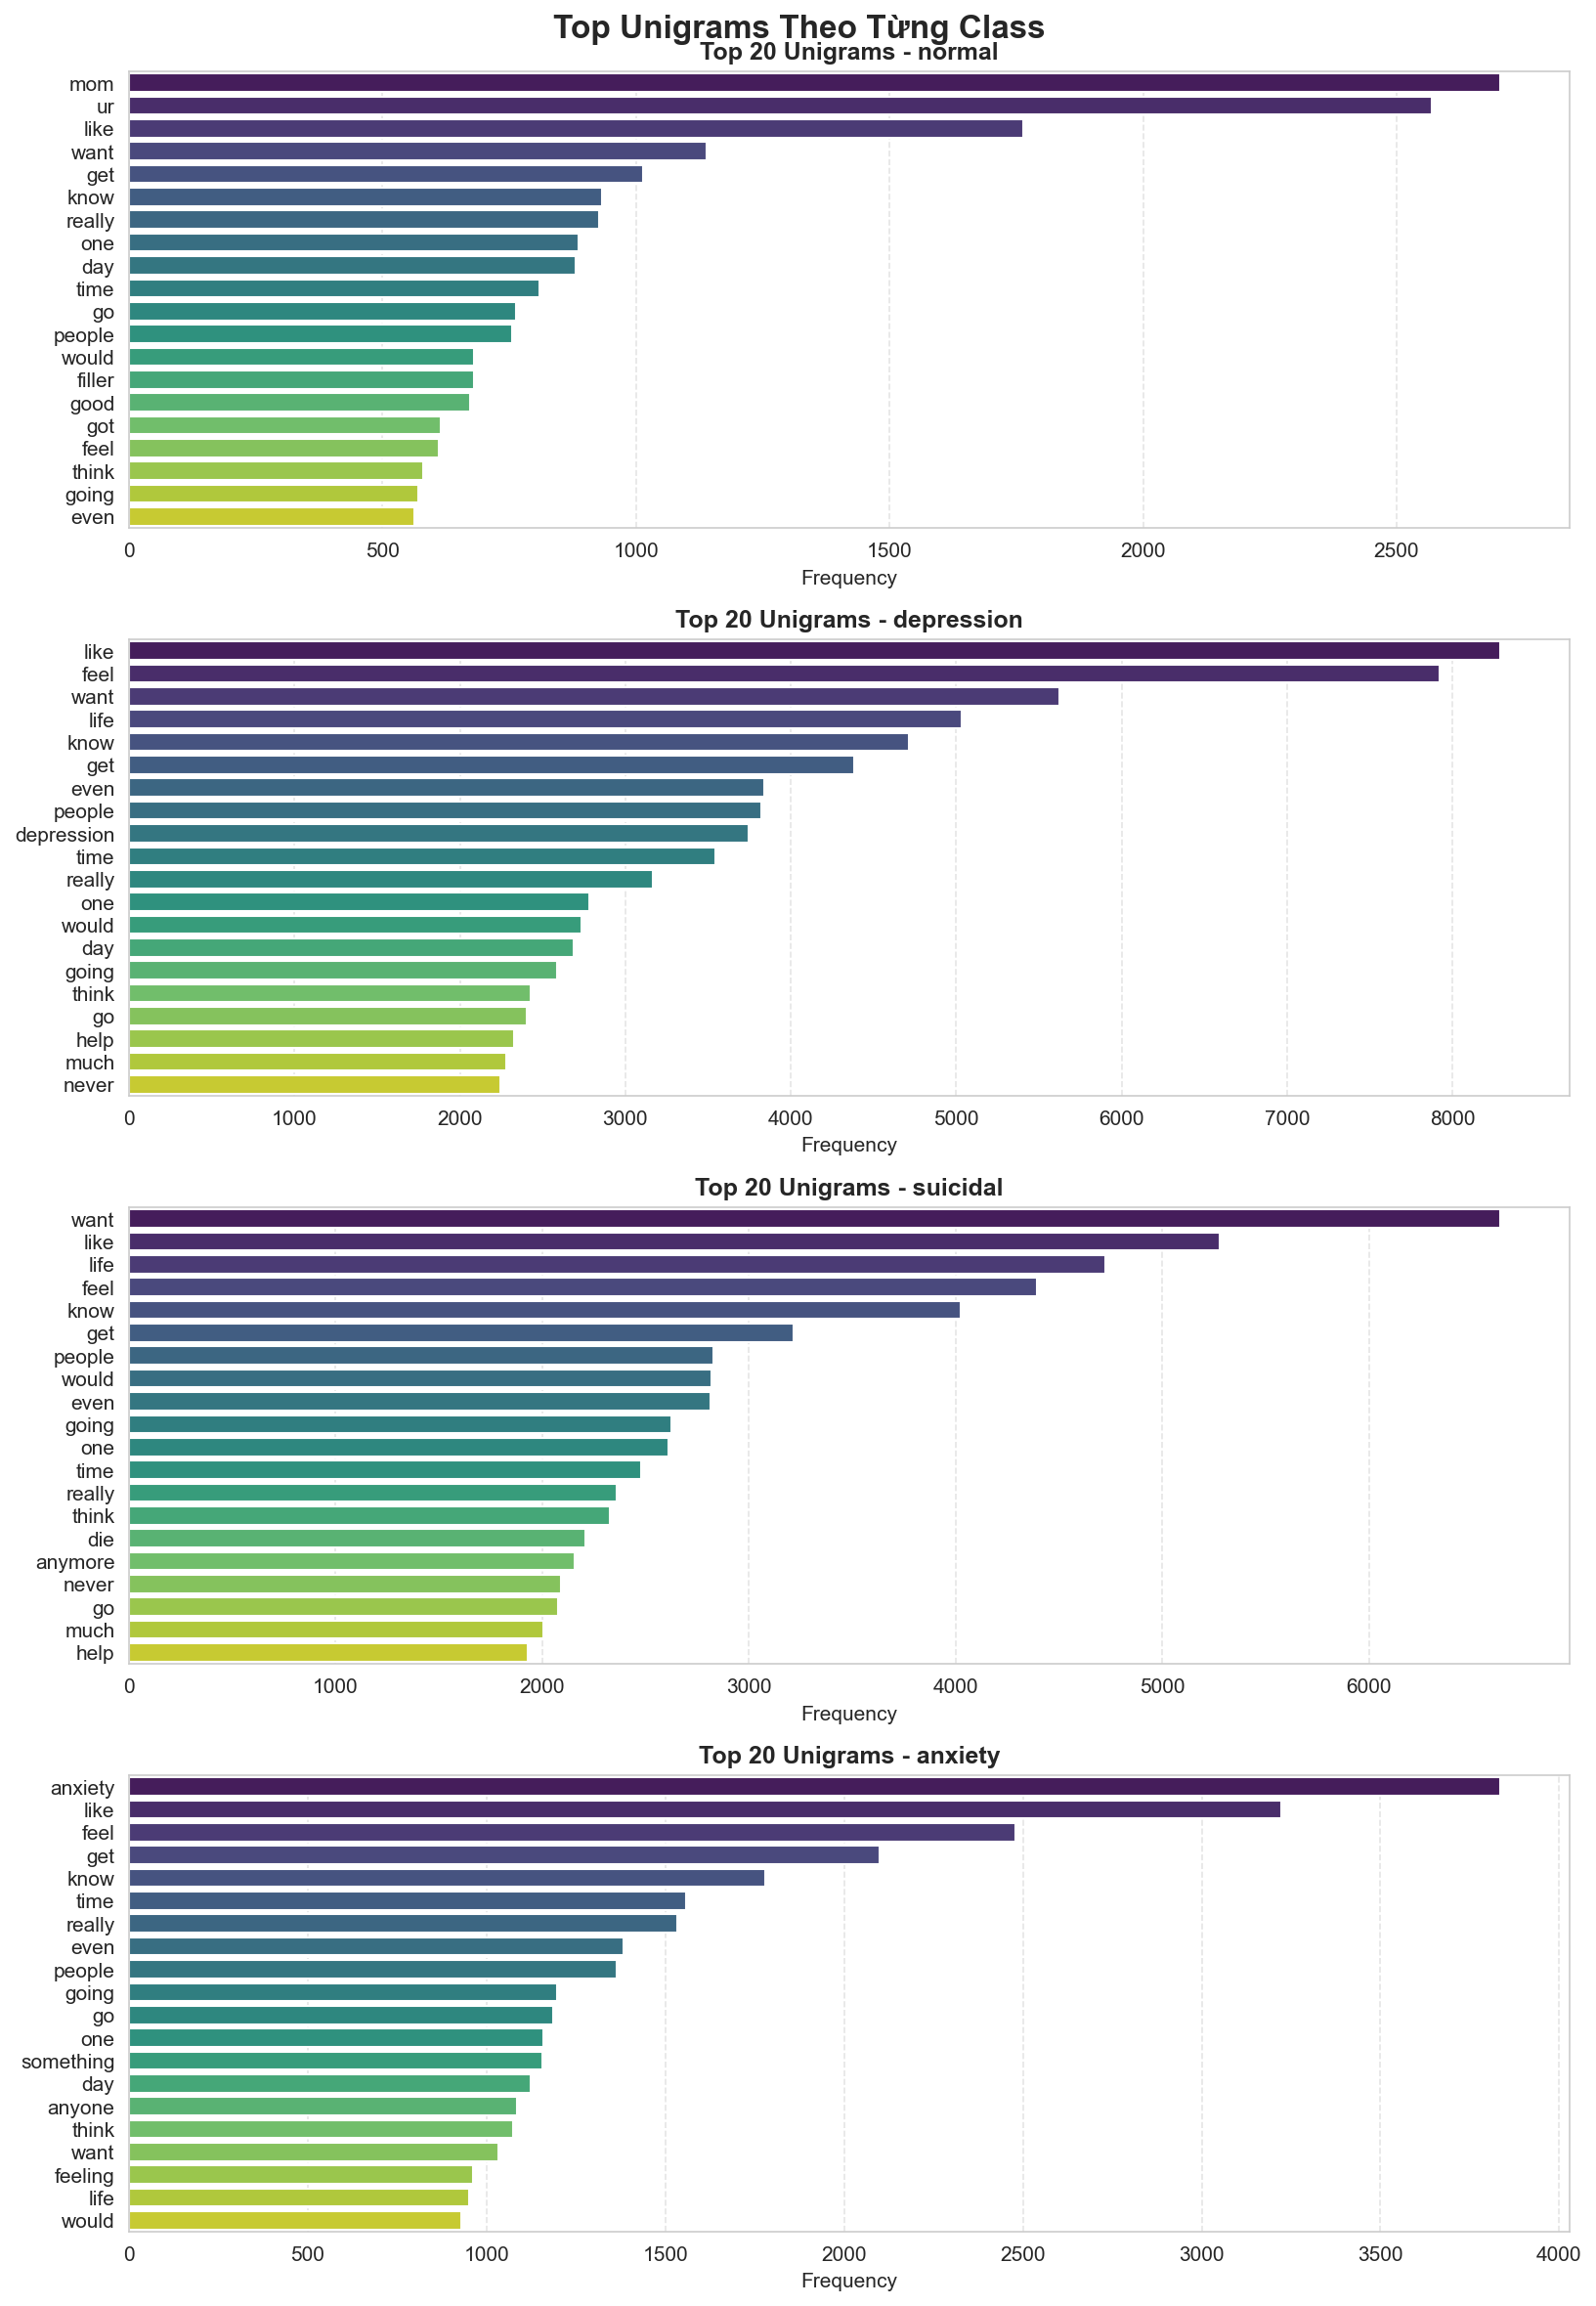


Vẽ top bigrams...


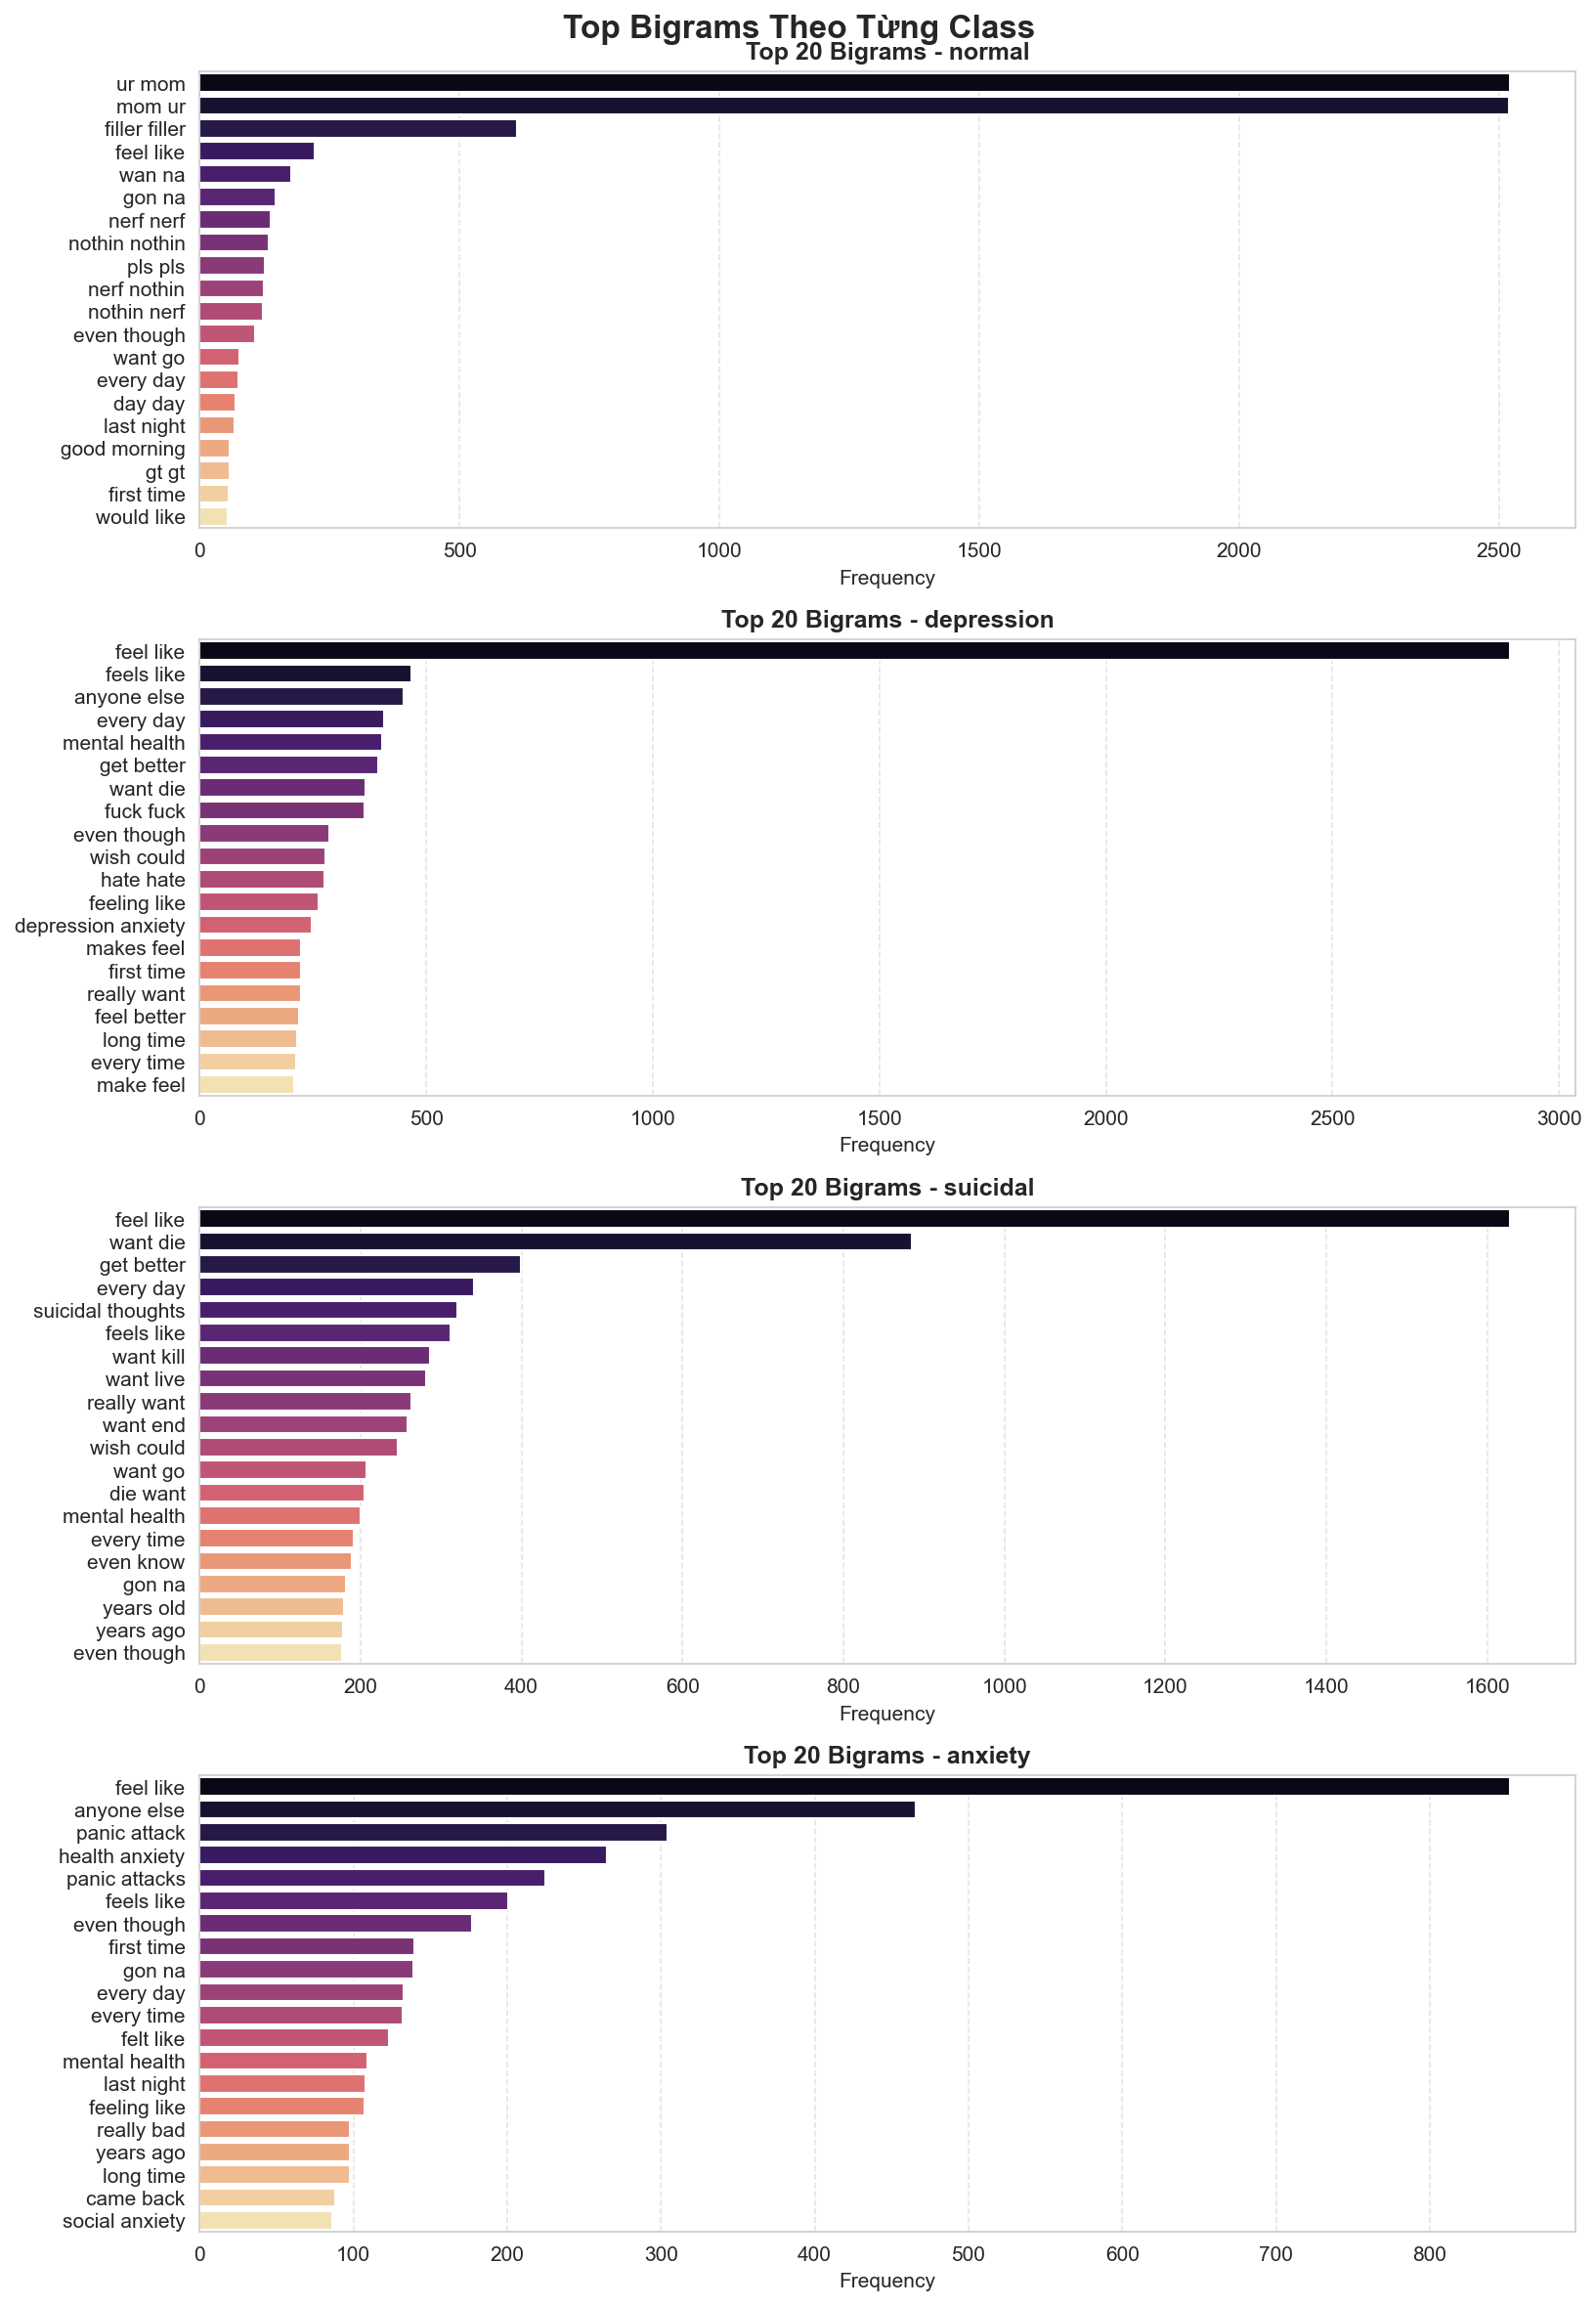


Đang tính TF-IDF...


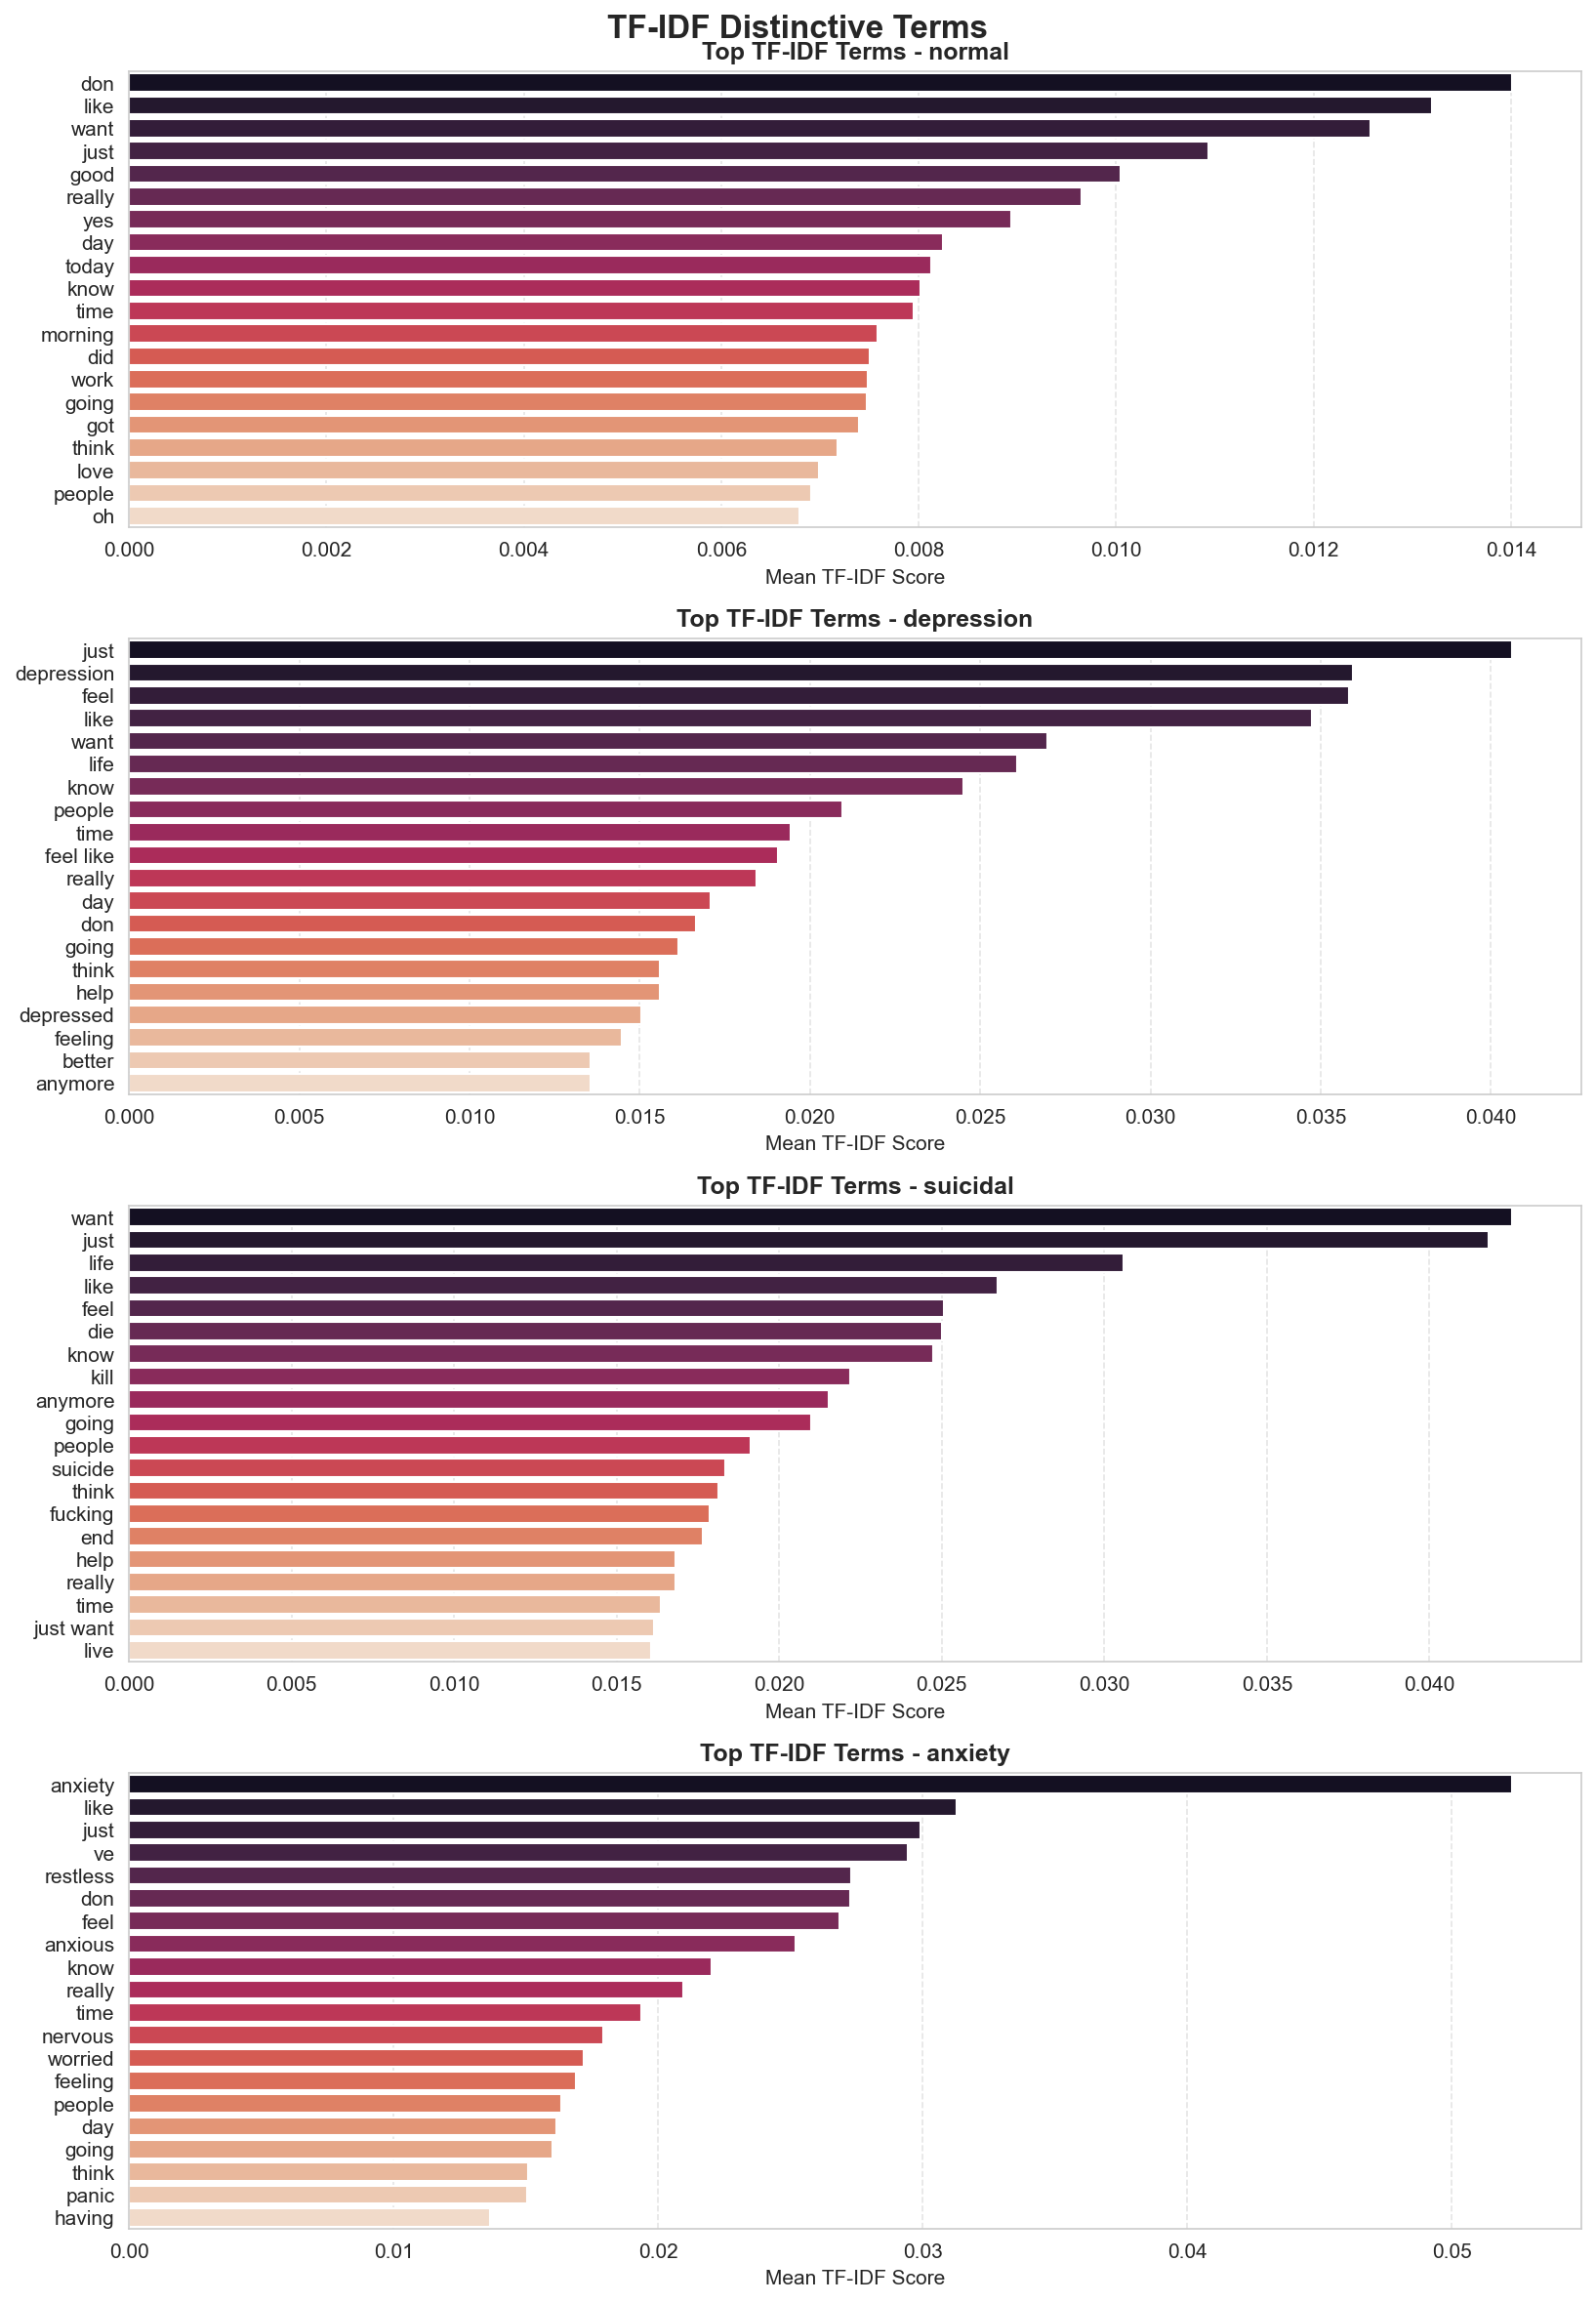

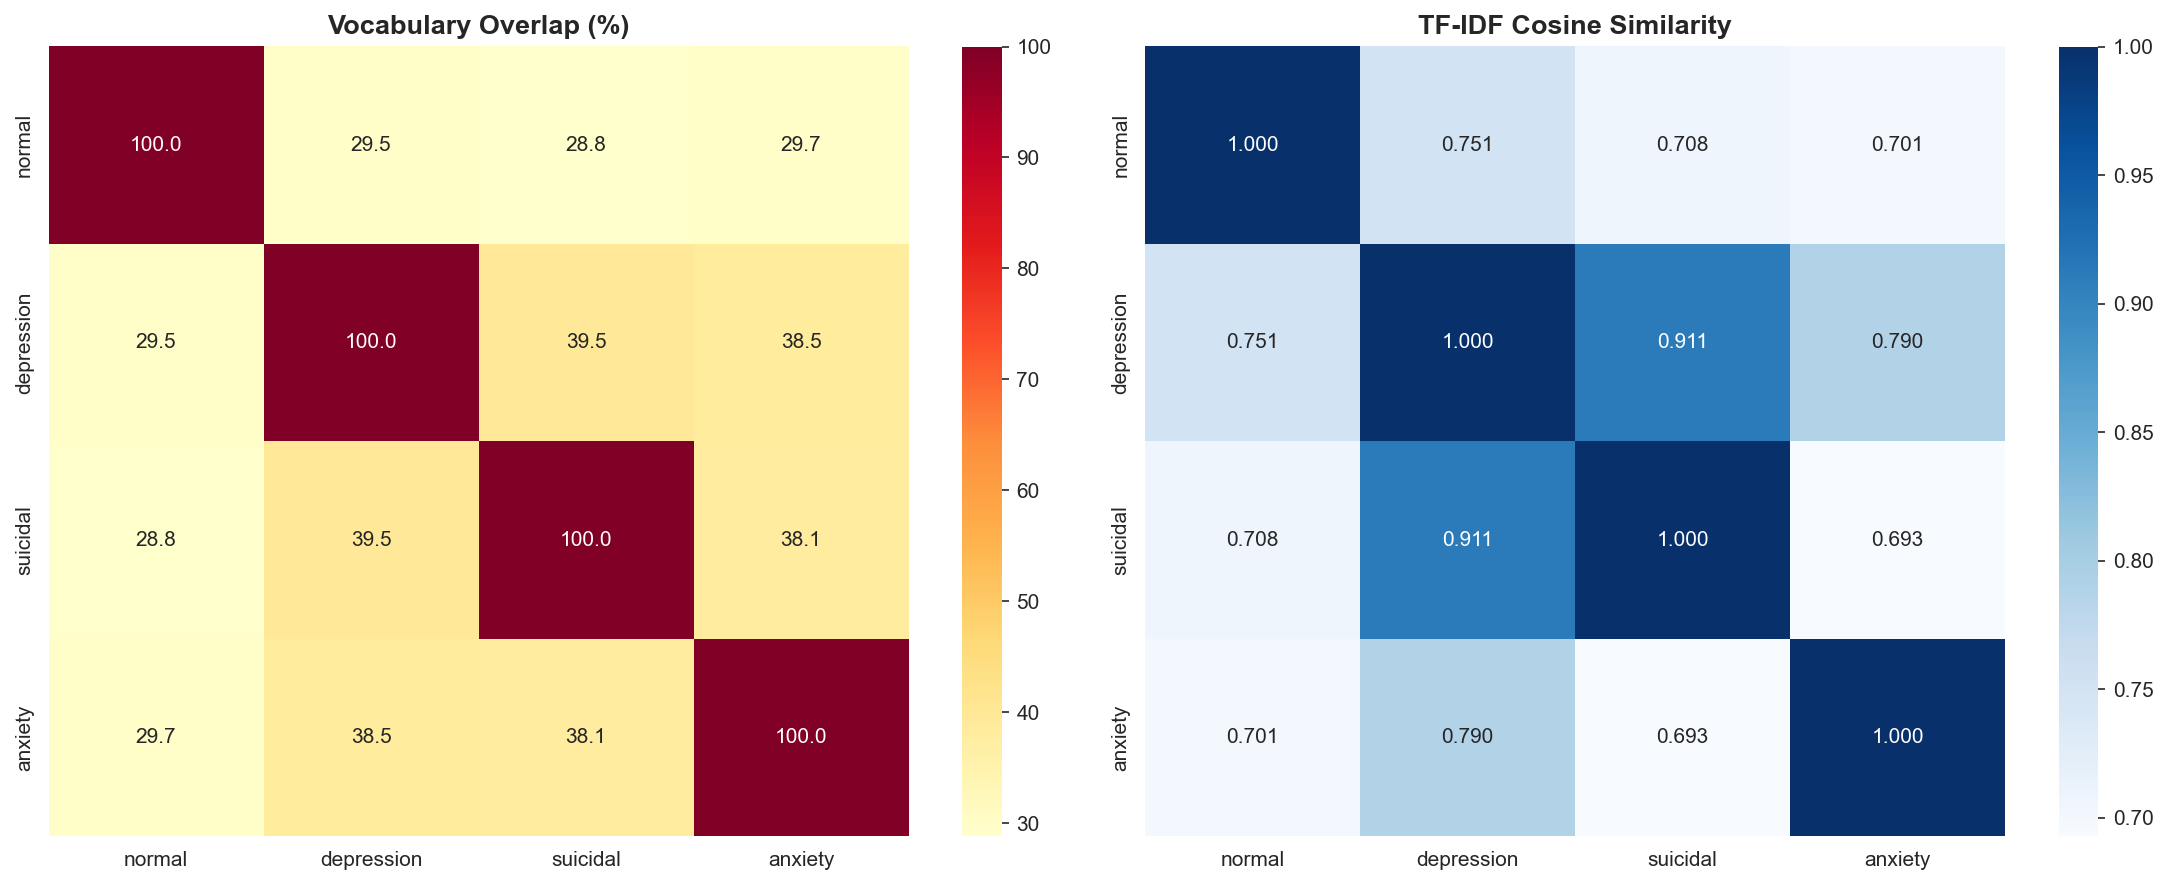

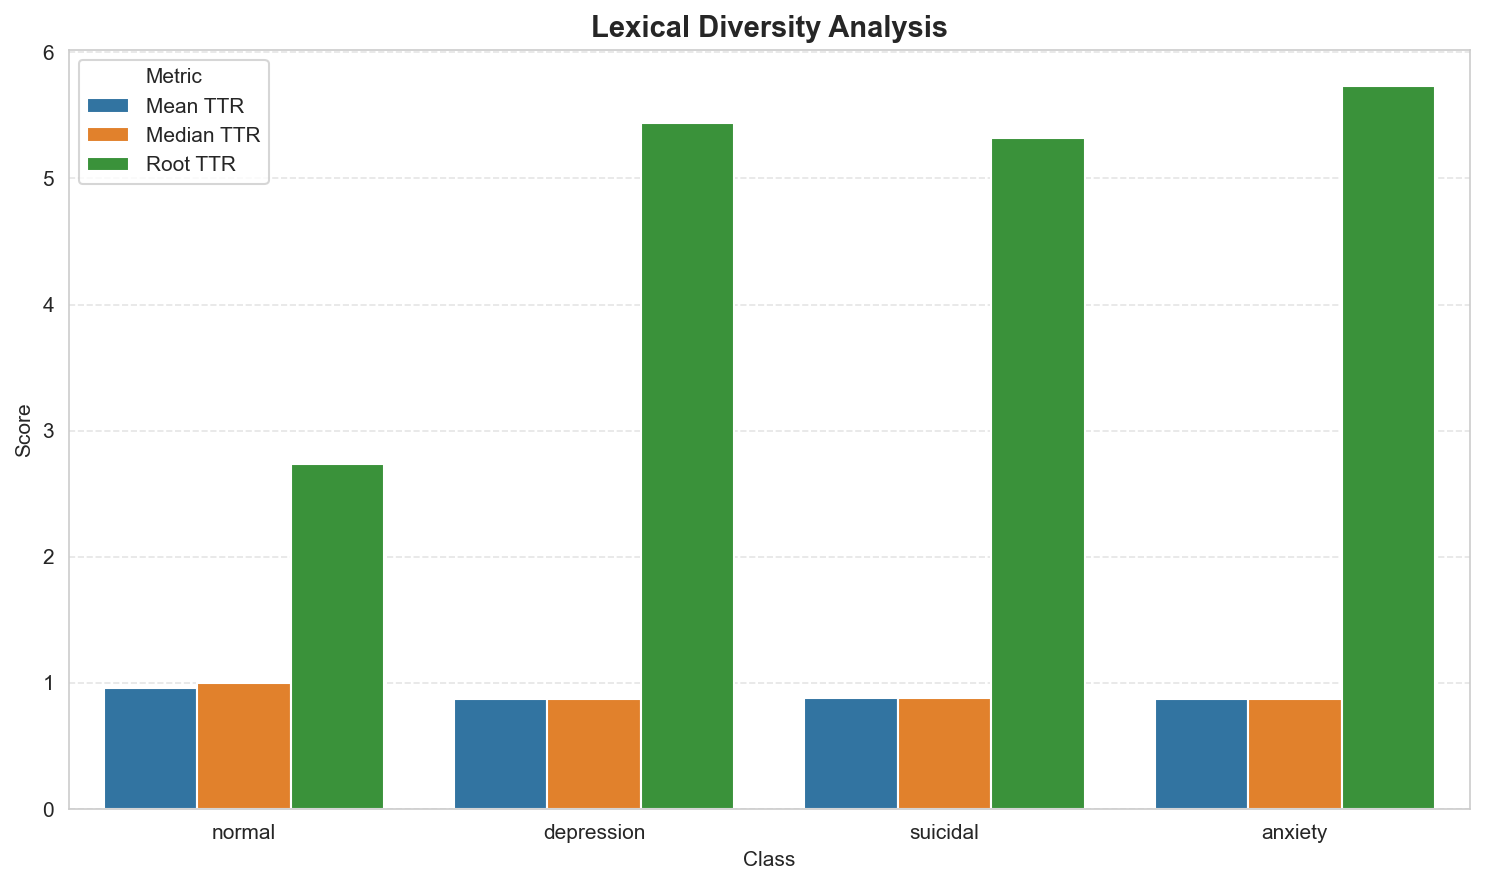


Hoàn tất vocabulary analysis.


,text,status,word_count,char_count,tokens
0,My ex has been there for me through everything.. We met in high school and I loved her. Eventually we had our on and offs but we stayed friendly. We would be affectionate even though we were not together. Recently she has been distant and it worried me. My grandma passed away on the first of Jul...,suicidal,157,784,"[ex, everything, met, high, school, loved, eventually, offs, stayed, friendly, would, affectionate, even, though, together, recently, distant, worried, grandma, passed, away, first, july, tells, finally, moving, even, spent, long, holding, hands, making, memories, together, world, falling, apart..."
1,"I have been struggling with severe depression and anxiety for years and have been cut off from treatment since the start of the pandemic. Recently I booked myself an online psychiatrist and therapist, since I do not want to risk going to a clinic. But every service has been fully booked until th...",suicidal,137,743,"[struggling, severe, depression, anxiety, years, cut, treatment, since, start, pandemic, recently, booked, online, psychiatrist, therapist, since, want, risk, going, clinic, every, service, fully, booked, next, month, meanwhile, alternative, options, peer, support, using, mental, health, apps, h..."
2,"this has probably happened hundreds of times in my lifetime. i'm 50 now, so obviously i haven't succumbed to depression yet. but the peaks and valleys are insane; i guess i'm insane. yesterday it fully made sense to me - if i had had immediate means to end my life i could see taking that action....",depression,132,701,"[probably, happened, hundreds, times, lifetime, obviously, succumbed, depression, yet, peaks, valleys, insane, guess, insane, yesterday, fully, made, sense, immediate, means, end, life, could, see, taking, action, never, gun, live, tall, building, far, small, voice, says, get, better, wait, rema..."
3,"everytime they something like when you have kids, when you are getting married when you get to university etc. it feels so bad to know i won't achieve anything in my life, my mom really loves kids and trusts me to get kids too and i for sure know that won't ever happen. i don't think i'm even go...",anxiety,85,421,"[everytime, something, like, kids, getting, married, get, university, etc, feels, bad, know, achieve, anything, life, mom, really, loves, kids, trusts, get, kids, sure, know, ever, happen, think, even, going, gf, ever, accepted, things, happen, parents, clue, hate, let]"
4,grahamcracker if only you were working in the melbourne victoria police department or the melbourne city cab,normal,17,108,"[grahamcracker, working, melbourne, victoria, police, department, melbourne, city, cab]"
...,...,...,...,...,...
35417,Blahhhhhhhhh,normal,1,12,[blahhhhhhhhh]
35418,"i feel like I am losing my best friend, she does not seem the same around me anymore and avoids affection (which usually she is very affectionate so that rlly worries me lol) idk hwat to do,,,, if i lose her i will have no future bc my future was supposed to b with her,, i want to kill myself help",suicidal,61,298,"[feel, like, losing, best, friend, seem, around, anymore, avoids, affection, usually, affectionate, rlly, worries, lol, idk, hwat, lose, future, bc, future, supposed, want, kill, help]"
35419,can t tweet working over the head,normal,7,33,"[tweet, working, head]"
35420,"They say that being happy is simple, but no one ever said that being happy would be easy",normal,18,88,"[say, happy, simple, one, ever, said, happy, would, easy]"


In [53]:
vocabulary_analysis(df)

## 9 — FEATURE CORRELATION ANALYSIS

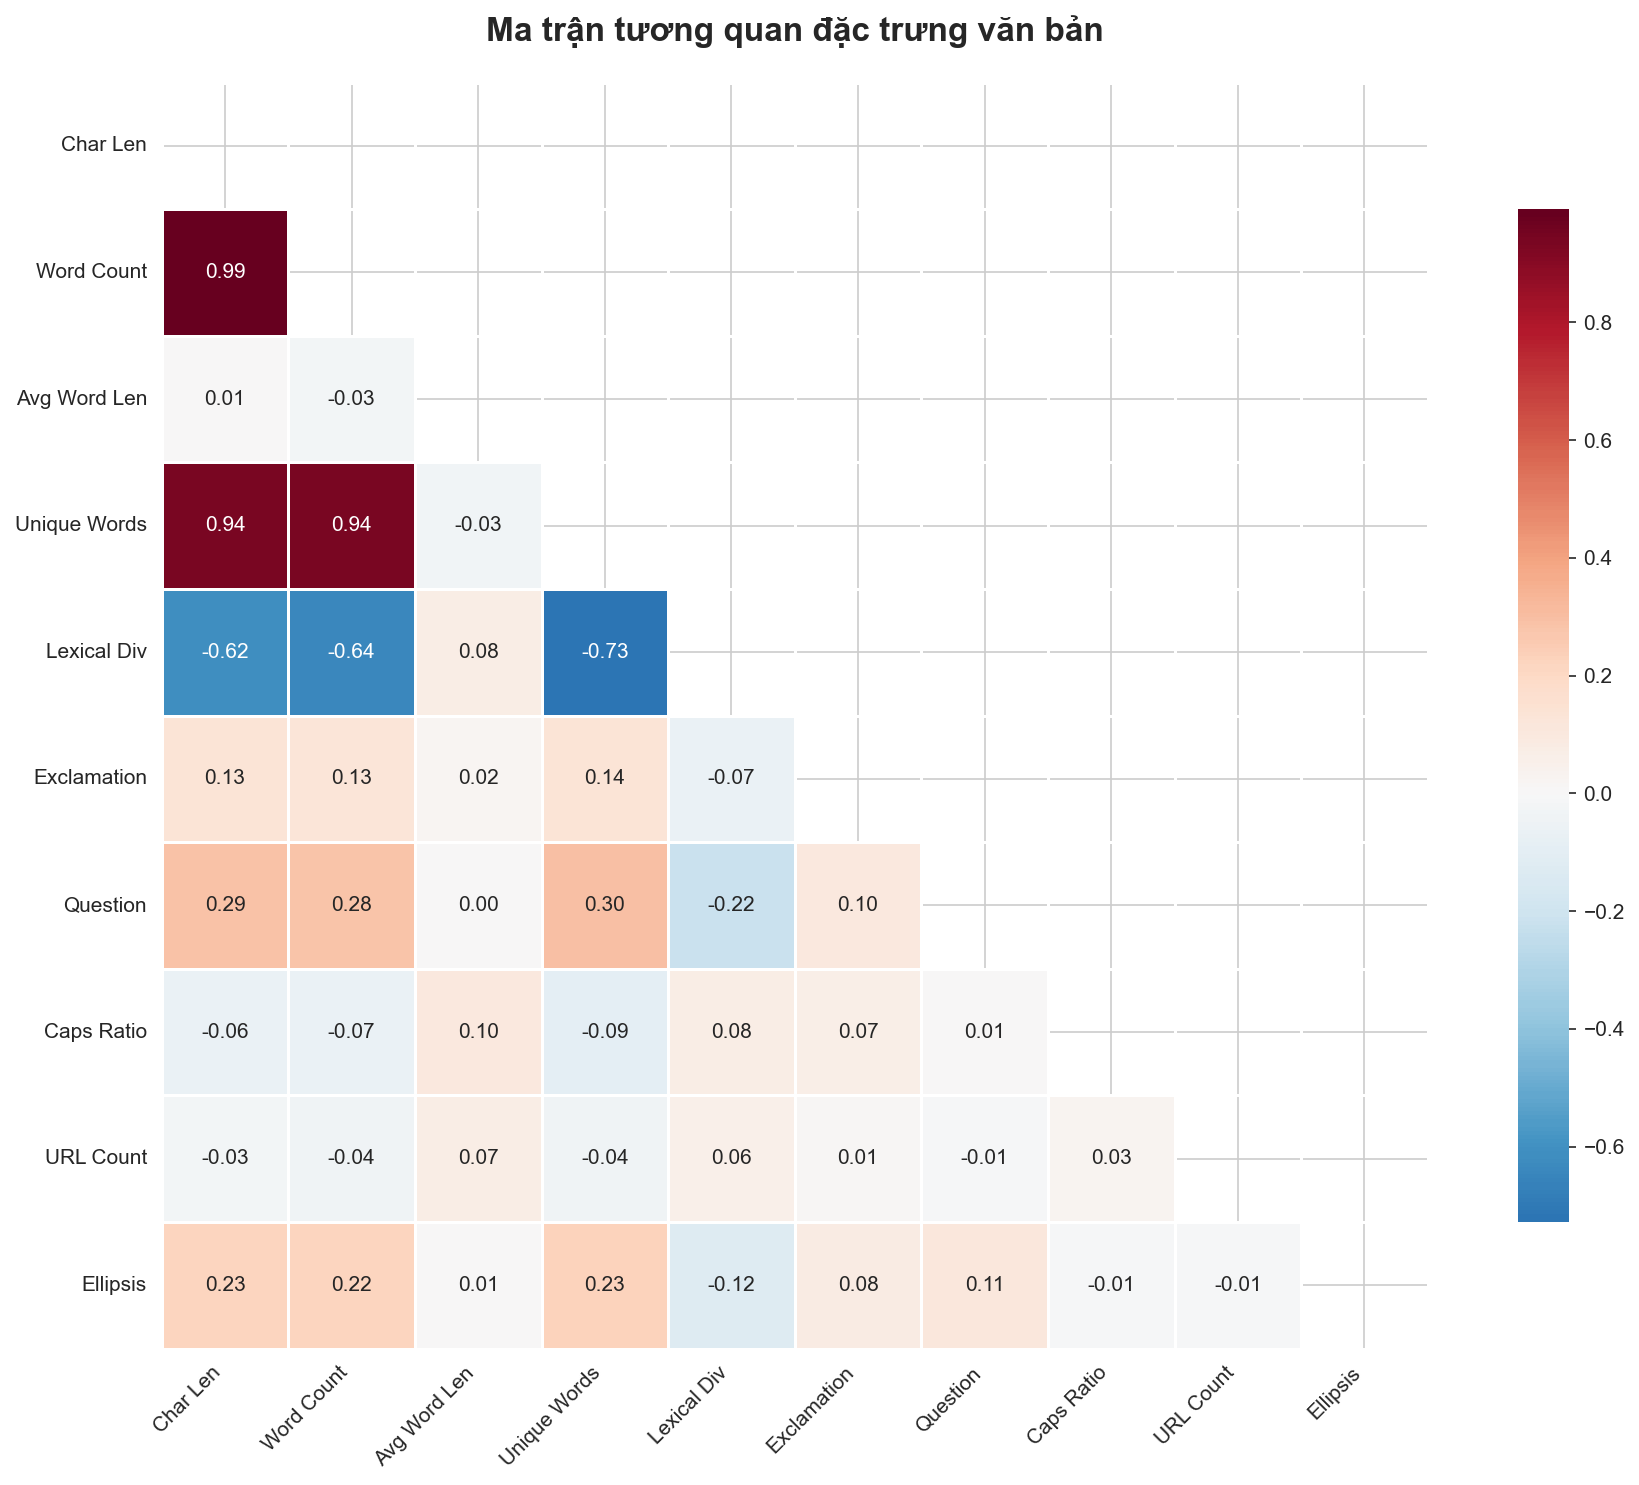

In [54]:
# Phân tích correlation giữa các text features
def feature_correlation_analysis(df):
    df = df.copy()
    # Ép text về string tránh lỗi NaN/object
    text_series = df[TEXT_COL].astype(str)
    # Tính các feature cơ bản nếu chưa tồn tại
    if 'char_len' not in df.columns:
        df['char_len'] = text_series.str.len()
    if 'word_count' not in df.columns:
        df['word_count'] = text_series.str.split().str.len()
    # Tính unique words tối ưu hơn apply(set(...))
    if 'unique_words' not in df.columns:
        df['unique_words'] = (
            text_series
            .str.lower()
            .str.split()
            .apply(lambda x: len(set(x)))
        )

    # Avg word length
    df['avg_word_len'] = (df['char_len'] /df['word_count'].replace(0, np.nan)).fillna(0)
    # Lexical diversity
    df['lexical_diversity'] = (df['unique_words'] /df['word_count'].replace(0, np.nan)).fillna(0)
    # Count punctuation features
    df['exclam_count'] = text_series.str.count(r'!')
    df['question_count'] = text_series.str.count(r'\?')
    df['ellipsis_count'] = text_series.str.count(r'\.\.\.')
    # URL count
    df['url_count'] = text_series.str.count(r'http')
    # Caps ratio tối ưu hơn apply từng char
    upper_counts = text_series.str.count(r'[A-Z]')
    df['caps_ratio'] = (upper_counts /df['char_len'].replace(0, np.nan)).fillna(0)
    # Danh sách features
    feature_cols = [
        'char_len',
        'word_count',
        'avg_word_len',
        'unique_words',
        'lexical_diversity',
        'exclam_count',
        'question_count',
        'caps_ratio',
        'url_count',
        'ellipsis_count'
    ]

    # Tên hiển thị đẹp hơn
    feature_labels = [
        'Char Len',
        'Word Count',
        'Avg Word Len',
        'Unique Words',
        'Lexical Div',
        'Exclamation',
        'Question',
        'Caps Ratio',
        'URL Count',
        'Ellipsis'
    ]

    # Tính correlation matrix
    corr_matrix = df[feature_cols].corr()
    # Rename rows/columns cho đẹp
    corr_matrix.index = feature_labels
    corr_matrix.columns = feature_labels

    # Tạo mask ẩn nửa trên heatmap
    mask = np.triu(
        np.ones_like(corr_matrix, dtype=bool)
    )

    # Visualization
    plt.figure(figsize=(13, 10))
    sns.heatmap(
        corr_matrix,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8}
    )
    plt.title("Ma trận tương quan đặc trưng văn bản", fontsize=16, fontweight='bold', pad=20)
    plt.xticks( rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()

    # Save figure
    if SAVE_FIGURES:
        plt.savefig(
            os.path.join(
                FIG_DIR,
                "feature_correlation_heatmap.png"
            ),
            dpi=DPI,
            bbox_inches='tight'
        )
    # Show figure
    if SHOW_FIGURES:
        plt.show()
    # Giải phóng RAM matplotlib
    plt.close()
    return df
# Run
df_features = feature_correlation_analysis(df)

## Feature and label analysis using ANOVA


Xếp hạng tầm quan trọng của tính năng:



,Feature,Original_Col,F_score,P_value
0,Lexical Div,lexical_diversity,7220.84,0.00e+00
1,Unique Words,unique_words,3265.21,0.00e+00
2,Word Count,word_count,1743.27,0.00e+00
3,Char Len,char_len,1633.41,0.00e+00
4,Question,question_count,434.75,2.13e-277
5,Caps Ratio,caps_ratio,166.96,1.77e-107
6,Exclamation,exclam_count,115.74,1.39e-74
7,Ellipsis,ellipsis_count,78.14,2.26e-50
8,Avg Word Len,avg_word_len,29.87,2.80e-19
9,URL Count,url_count,2.39,6.63e-02


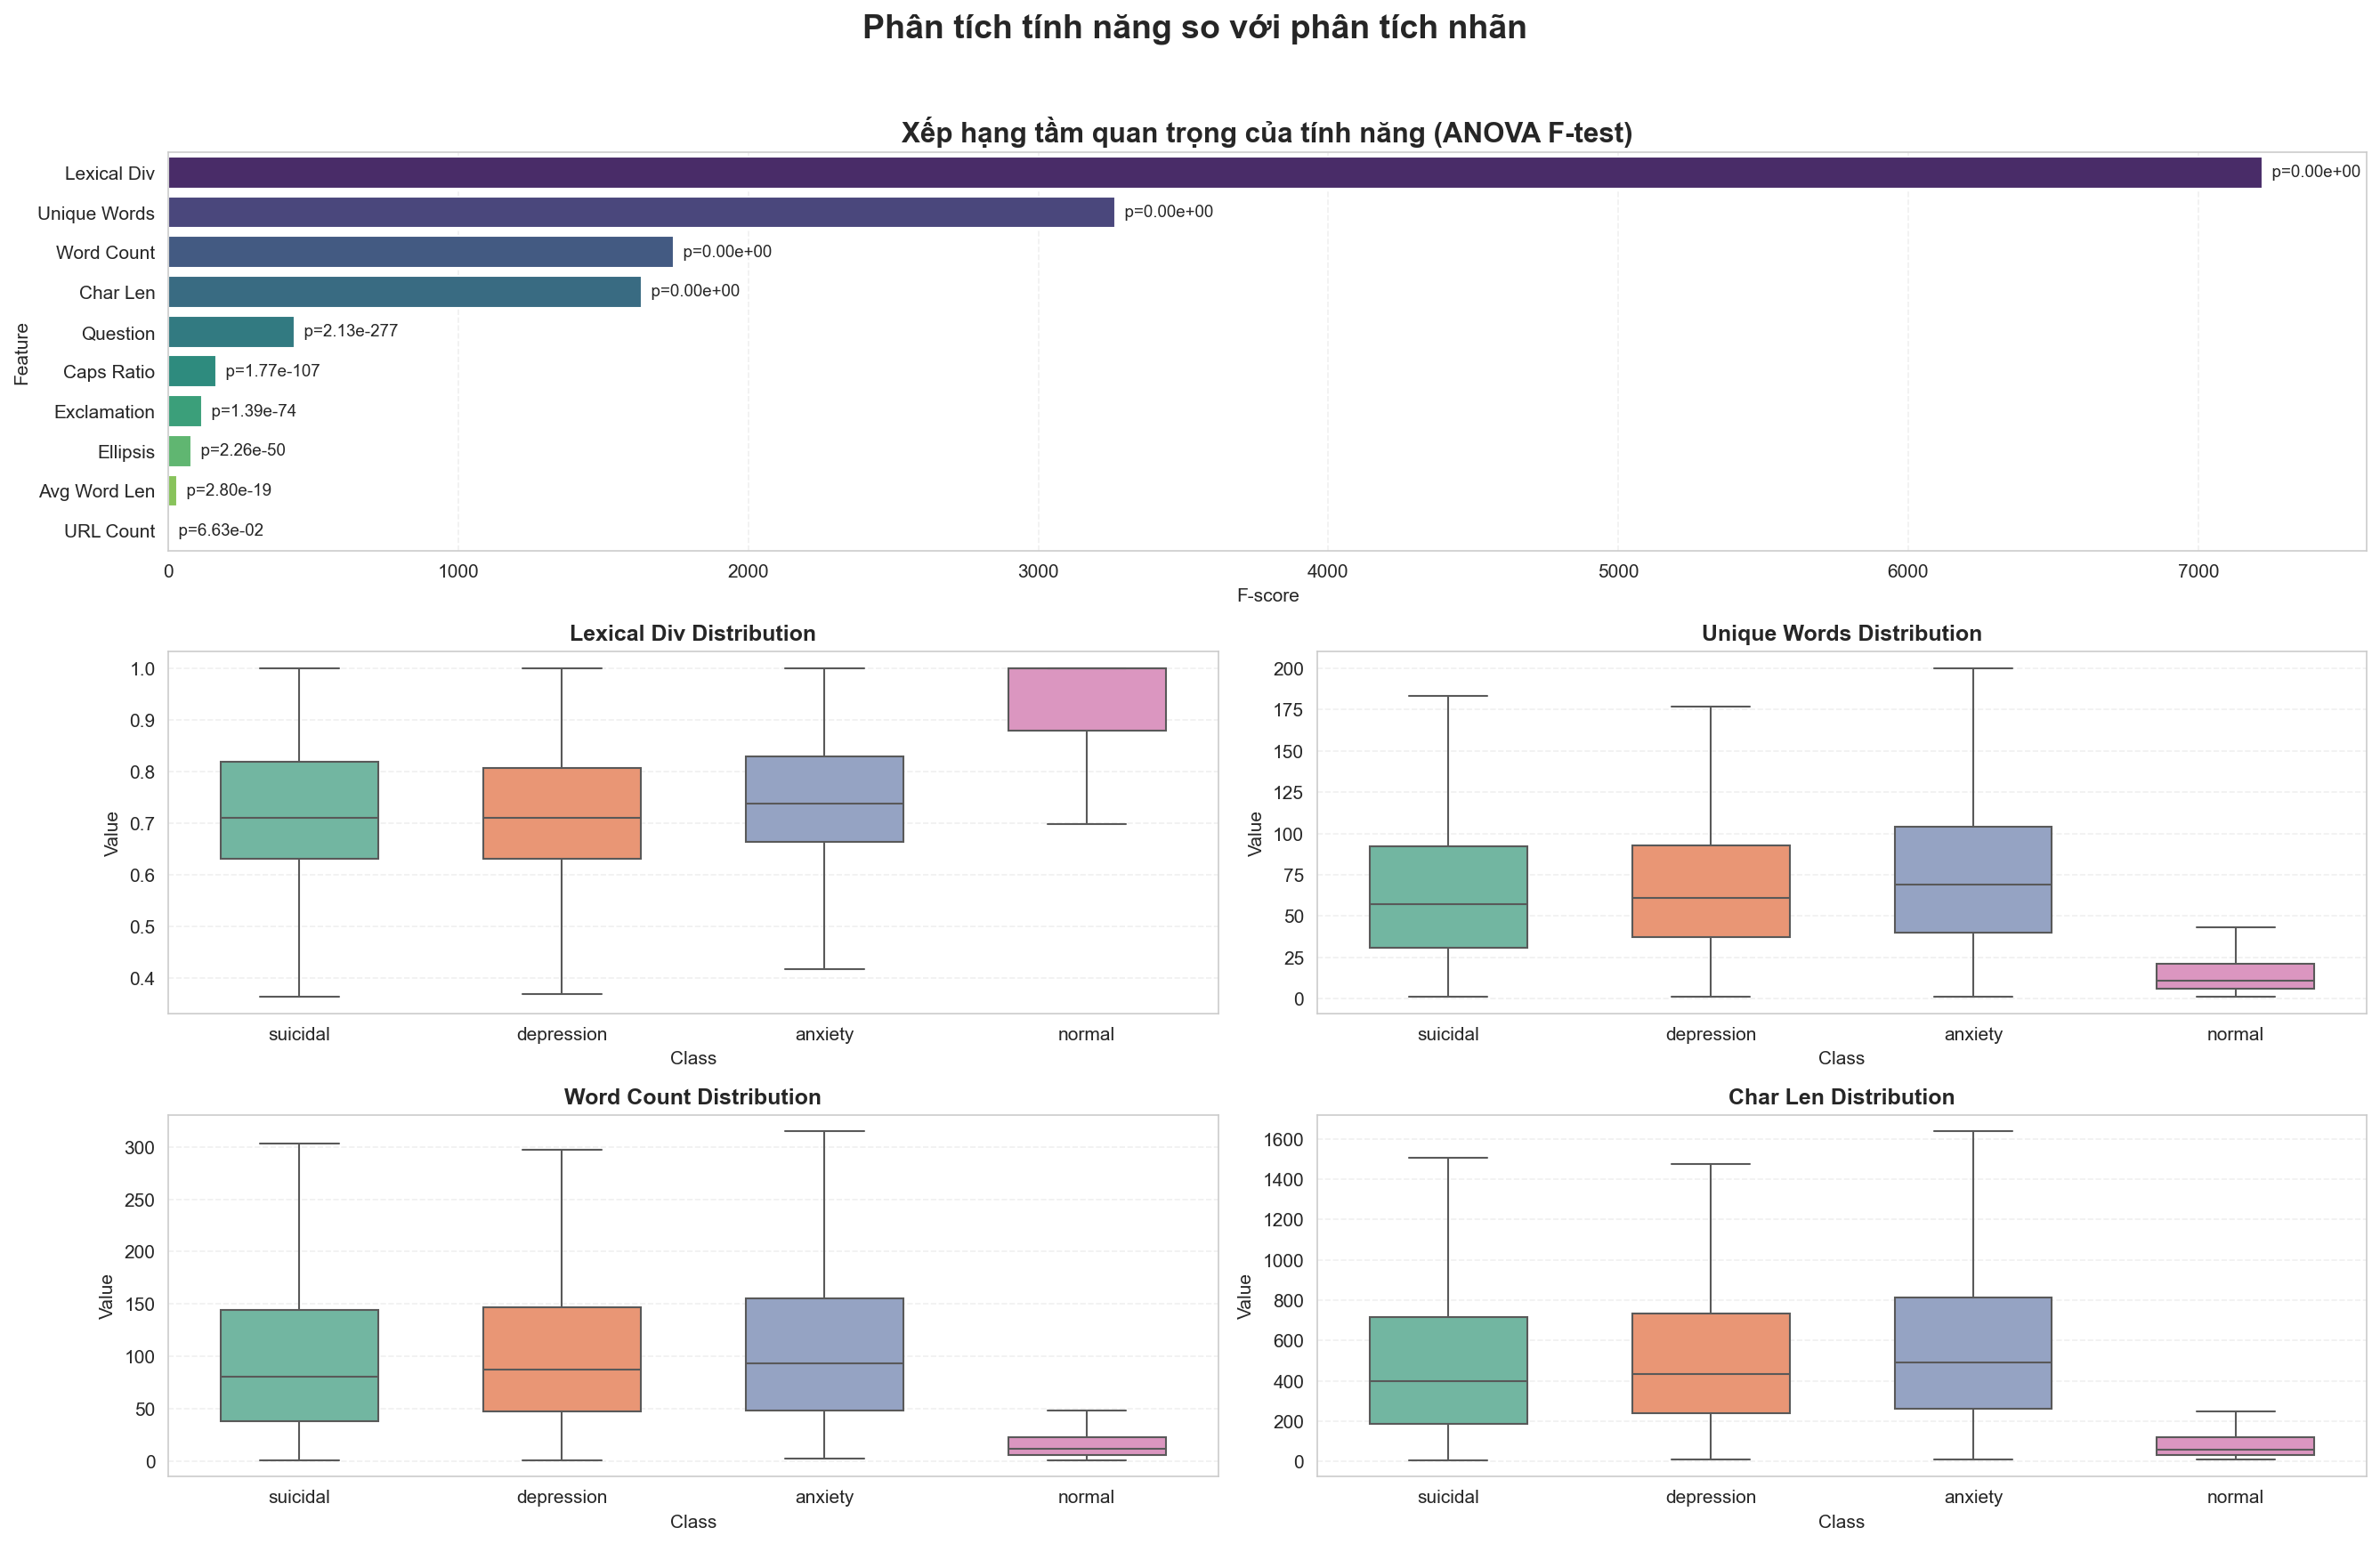

In [55]:
# Phân tích mối quan hệ giữa feature và label bằng ANOVA
def feature_label_analysis(df):
    df = df.copy()
    feature_cols = [
        'char_len',
        'word_count',
        'avg_word_len',
        'unique_words',
        'lexical_diversity',
        'exclam_count',
        'question_count',
        'caps_ratio',
        'url_count',
        'ellipsis_count'
    ]
    feature_labels = [
        'Char Len',
        'Word Count',
        'Avg Word Len',
        'Unique Words',
        'Lexical Div',
        'Exclamation',
        'Question',
        'Caps Ratio',
        'URL Count',
        'Ellipsis'
    ]

    # Nếu thiếu feature thì tự động build lại
    missing_features = [
        col for col in feature_cols
        if col not in df.columns
    ]

    if len(missing_features) > 0:
        print("Thiếu feature -> Tự động tạo lại features...")
        df = feature_correlation_analysis(df)

    # Encode labels sang dạng số
    le = LabelEncoder()
    y = le.fit_transform(df[LABEL_COL].astype(str))
    # Tính ANOVA F-score
    f_scores, p_values = f_classif(df[feature_cols], y)
    importance_df = pd.DataFrame({
        "Feature": feature_labels,
        "Original_Col": feature_cols,
        "F_score": f_scores,
        "P_value": p_values
    })

    # Sort theo F-score giảm dần
    importance_df = (
        importance_df
        .sort_values(
            by="F_score",
            ascending=False
        )
        .reset_index(drop=True)
    )
    # In bảng kết quả
    print("\nXếp hạng tầm quan trọng của tính năng:\n")
    display(
        importance_df.style.format({
            "F_score": "{:.2f}",
            "P_value": "{:.2e}"
        })
    )

    # == Bố cục trực quan ==
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 2, height_ratios=[1.1, 1, 1])

    # BARPLOT FEATURE IMPORTANCE

    ax_bar = fig.add_subplot(gs[0, :])

    colors = sns.color_palette(
        "viridis",
        len(importance_df)
    )

    sns.barplot(
        data=importance_df,
        x="F_score",
        y="Feature",
        palette=colors,
        ax=ax_bar
    )

    ax_bar.set_title(
        "Xếp hạng tầm quan trọng của tính năng (ANOVA F-test)",
        fontsize=15,
        fontweight='bold'
    )
    ax_bar.set_xlabel("F-score")
    ax_bar.set_ylabel("Feature")

    # Hiển thị p-value
    for i, row in importance_df.iterrows():
        ax_bar.text(
            row["F_score"],
            i,
            f"  p={row['P_value']:.2e}",
            va='center',
            fontsize=9
        )

    # Grid nhẹ cho dễ đọc
    ax_bar.grid(
        axis='x',
        linestyle='--',
        alpha=0.3
    )

    # TOP FEATURES BOXPLOT
    top_features = importance_df.head(4)
    for i, (_, row) in enumerate(top_features.iterrows()):
        ax = fig.add_subplot(
            gs[1 + i // 2, i % 2]
        )
        sns.boxplot(
            data=df,
            x=LABEL_COL,
            y=row["Original_Col"],
            palette='Set2',
            showfliers=False,
            width=0.6,
            ax=ax
        )
        ax.set_title(f"{row['Feature']} Distribution", fontsize=12, fontweight='bold')
        ax.set_xlabel("Class")
        ax.set_ylabel("Value")
        ax.grid(axis='y', linestyle='--', alpha=0.3)

    # FINAL LAYOUT
    plt.suptitle("Phân tích tính năng so với phân tích nhãn", fontsize=18, fontweight='bold')
    plt.tight_layout(rect=[0, 0.02, 1, 0.96])
    # Save figure
    if SAVE_FIGURES:
        plt.savefig(
            os.path.join(
                FIG_DIR,
                "feature_label_analysis.png"
            ),
            dpi=DPI,
            bbox_inches='tight'
        )

    # Show figure
    if SHOW_FIGURES:
        plt.show()
    # Giải phóng RAM matplotlib
    plt.close()
    return importance_df
# Run
importance_df = feature_label_analysis(df_features)

In [56]:
def data_quality_analysis(df):
    print("\n===== Phân tích Chất lượng dữ liệu =====")
    df = df.copy()

    # ----- Các hàm phát hiện noise -----
    def count_non_ascii(text):
        return sum(1 for c in str(text) if ord(c) > 127)

    def count_urls(text):
        return len(re.findall(r'http[s]?://\S+|www\.\S+', str(text)))

    def count_mentions(text):
        return len(re.findall(r'@\w+', str(text)))

    # MỚI: Hàm đếm hashtag
    def count_hashtags(text):
        return len(re.findall(r'#\w+', str(text)))

    def count_repeated_chars(text, n=5):
        return len(re.findall(r'(.)\1{' + str(n-1) + r',}', str(text)))

    def is_short_text(text, thresh=SHORT_TEXT_THRESHOLD):
        return len(str(text).split()) <= thresh

    def has_html(text):
        html_pattern = re.compile(r'<(?!(?:username|url|user|name|number)\b)[^>]+>')
        return bool(html_pattern.search(str(text)))

    # ----- Phát hiện emoji -----
    try:
        import emoji
        def has_emoji(text):
            return bool(emoji.emoji_count(str(text)))
    except ImportError:
        emoji_pattern = re.compile(
            "["
            "\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF"
            "\U0001F1E0-\U0001F1FF\U00002600-\U000026FF\U00002700-\U000027BF"
            "\U0000FE00-\U0000FE0F\U0001F900-\U0001F9FF\U0001FA00-\U0001FA6F"
            "\U0001FA70-\U0001FAFF"
            "]+", flags=re.UNICODE)
        def has_emoji(text):
            return bool(emoji_pattern.search(str(text)))

    # ----- Phát hiện mojibake -----
    mojibake_pattern = re.compile(
        r'Ã[©¢£¤¥§]|Ã[¨©ª«¬­®¯]|â[€‚ƒ„…†‡ˆ‰Š‹ŒŽ]|â[‘’“”•–—˜™š›œžŸ]|Â[¡¢£¤¥¦§¨©ª«¬­®¯]')
    def has_mojibake(text):
        return bool(mojibake_pattern.search(str(text)))

    # ----- Gán cờ cho từng mẫu -----
    df['has_non_ascii'] = df[TEXT_COL].apply(lambda x: count_non_ascii(x) > 0)
    df['url_flag'] = df[TEXT_COL].apply(lambda x: count_urls(x) > 0)
    df['mention_flag'] = df[TEXT_COL].apply(lambda x: count_mentions(x) > 0)
    df['hashtag_flag'] = df[TEXT_COL].apply(lambda x: count_hashtags(x) > 0) # MỚI
    df['repeated_char'] = df[TEXT_COL].apply(lambda x: count_repeated_chars(x, 5) > 0)
    df['is_short'] = df[TEXT_COL].apply(is_short_text)
    df['has_emoji_flag'] = df[TEXT_COL].apply(has_emoji)
    df['has_mojibake_flag'] = df[TEXT_COL].apply(has_mojibake)
    df['has_html_flag'] = df[TEXT_COL].apply(has_html)

    # Tính tỉ lệ % tổng quát
    issue_dict = {
        'Non-ASCII': df['has_non_ascii'].mean() * 100,
        'Chứa URL': df['url_flag'].mean() * 100,
        'Chứa @mention': df['mention_flag'].mean() * 100,
        'Chứa #hashtag': df['hashtag_flag'].mean() * 100, # MỚI
        'Ký tự lặp (≥5)': df['repeated_char'].mean() * 100,
        'Văn bản ngắn': df['is_short'].mean() * 100,
        'Có emoji': df['has_emoji_flag'].mean() * 100,
        'Có mojibake': df['has_mojibake_flag'].mean() * 100,
        'Chứa HTML': df['has_html_flag'].mean() * 100
    }

    print("Tỉ lệ % các vấn đề trên toàn bộ dataset:")
    for k, v in issue_dict.items():
        print(f"  - {k}: {v:.2f}%")

    # 1. Biểu đồ thanh: Tổng quan các vấn đề
    plt.figure(figsize=(12, 5))
    bars = plt.bar(issue_dict.keys(), issue_dict.values(), color='#8B5CF6')
    plt.ylabel("Phần trăm (%) mẫu vi phạm")
    plt.title("Tổng quan các vấn đề chất lượng dữ liệu")
    plt.xticks(rotation=30, ha='right')
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.1f}%", ha='center')
    plt.tight_layout()
    if FIG_DIR:
        plt.savefig(os.path.join(FIG_DIR, "data_quality_overview.png"), dpi=DPI)
    plt.show()

    # 2. Biểu đồ Heatmap: Tỉ lệ vấn đề theo từng Lớp
    # TỔNG HỢP: Thêm 'hashtag_flag' vào list bên dưới
    cross = df.groupby(LABEL_COL)[['has_non_ascii', 'repeated_char', 'is_short',
                                   'url_flag', 'mention_flag', 'hashtag_flag', # MỚI
                                   'has_emoji_flag', 'has_mojibake_flag', 'has_html_flag']].mean() * 100

    cross.columns = ['Non-ASCII', 'Ký tự lặp', 'Ngắn', 'URL', '@Mention', 'Hashtag', 'Emoji', 'Mojibake', 'HTML']

    plt.figure(figsize=(14, 8))
    sns.heatmap(cross, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': 'Phần trăm (%)'})
    plt.title("Tỉ lệ vấn đề chất lượng dữ liệu phân bố theo Lớp")
    plt.xlabel("Loại vấn đề")
    plt.ylabel("Lớp (Class)")
    plt.tight_layout()
    if FIG_DIR:
        plt.savefig(os.path.join(FIG_DIR, "data_quality_by_class.png"), dpi=DPI)
    plt.show()

    # ----- Liệt kê các mẫu ví dụ (Sử dụng Sample ngẫu nhiên) -----
    print("\n--- Ví dụ các mẫu văn bản chứa lỗi (Lấy ngẫu nhiên) ---")
    noise_types = {
        'Chứa HTML': 'has_html_flag',
        'Chứa URL': 'url_flag',
        'Chứa Hashtag': 'hashtag_flag', # MỚI
        'Ký tự lặp': 'repeated_char',
        'Mojibake': 'has_mojibake_flag',
        'Văn bản ngắn': 'is_short'
    }

    for noise_name, flag_col in noise_types.items():
        subset = df[df[flag_col]][TEXT_COL]
        n_total = len(subset)
        n_samples = min(5, n_total) # Lấy tối đa 5 mẫu

        print(f"\n{noise_name} (Tổng {n_total} mẫu):")
        if n_samples == 0:
            print("  (Không tìm thấy mẫu nào)")
        else:
            samples = subset.sample(n_samples, random_state=1000)
            for i, text in enumerate(samples, 1):
                display_text = str(text).replace('\n', ' ')
                print(f"  [{i}] {display_text}")

In [57]:
def data_quality_analysis(df):
    print("\n===== Phân tích Chất lượng dữ liệu =====")
    df = df.copy()

    # ----- Các hàm phát hiện noise -----
    def count_non_ascii(text):
        return sum(1 for c in str(text) if ord(c) > 127)

    def count_urls(text):
        return len(re.findall(r'http[s]?://\S+|www\.\S+', str(text)))

    def count_mentions(text):
        return len(re.findall(r'@\w+', str(text)))

    # MỚI: Hàm đếm hashtag
    def count_hashtags(text):
        return len(re.findall(r'#\w+', str(text)))

    def count_repeated_chars(text, n=5):
        return len(re.findall(r'(.)\1{' + str(n-1) + r',}', str(text)))

    def is_short_text(text, thresh=SHORT_TEXT_THRESHOLD):
        return len(str(text).split()) <= thresh

    def has_html(text):
        html_pattern = re.compile(r'<(?!(?:username|url|user|name|number)\b)[^>]+>')
        return bool(html_pattern.search(str(text)))

    # ----- Phát hiện emoji -----
    try:
        import emoji
        def has_emoji(text):
            return bool(emoji.emoji_count(str(text)))
    except ImportError:
        emoji_pattern = re.compile(
            "["
            "\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF"
            "\U0001F1E0-\U0001F1FF\U00002600-\U000026FF\U00002700-\U000027BF"
            "\U0000FE00-\U0000FE0F\U0001F900-\U0001F9FF\U0001FA00-\U0001FA6F"
            "\U0001FA70-\U0001FAFF"
            "]+", flags=re.UNICODE)
        def has_emoji(text):
            return bool(emoji_pattern.search(str(text)))

    # ----- Phát hiện mojibake -----
    mojibake_pattern = re.compile(
        r'Ã[©¢£¤¥§]|Ã[¨©ª«¬­®¯]|â[€‚ƒ„…†‡ˆ‰Š‹ŒŽ]|â[‘’“”•–—˜™š›œžŸ]|Â[¡¢£¤¥¦§¨©ª«¬­®¯]')
    def has_mojibake(text):
        return bool(mojibake_pattern.search(str(text)))

    # ----- Gán cờ cho từng mẫu -----
    df['has_non_ascii'] = df[TEXT_COL].apply(lambda x: count_non_ascii(x) > 0)
    df['url_flag'] = df[TEXT_COL].apply(lambda x: count_urls(x) > 0)
    df['mention_flag'] = df[TEXT_COL].apply(lambda x: count_mentions(x) > 0)
    df['hashtag_flag'] = df[TEXT_COL].apply(lambda x: count_hashtags(x) > 0) # MỚI
    df['repeated_char'] = df[TEXT_COL].apply(lambda x: count_repeated_chars(x, 5) > 0)
    df['is_short'] = df[TEXT_COL].apply(is_short_text)
    df['has_emoji_flag'] = df[TEXT_COL].apply(has_emoji)
    df['has_mojibake_flag'] = df[TEXT_COL].apply(has_mojibake)
    df['has_html_flag'] = df[TEXT_COL].apply(has_html)

    # Tính tỉ lệ % tổng quát
    issue_dict = {
        'Non-ASCII': df['has_non_ascii'].mean() * 100,
        'Chứa URL': df['url_flag'].mean() * 100,
        'Chứa @mention': df['mention_flag'].mean() * 100,
        'Chứa #hashtag': df['hashtag_flag'].mean() * 100, # MỚI
        'Ký tự lặp (≥5)': df['repeated_char'].mean() * 100,
        'Văn bản ngắn': df['is_short'].mean() * 100,
        'Có emoji': df['has_emoji_flag'].mean() * 100,
        'Có mojibake': df['has_mojibake_flag'].mean() * 100,
        'Chứa HTML': df['has_html_flag'].mean() * 100
    }

    print("Tỉ lệ % các vấn đề trên toàn bộ dataset:")
    for k, v in issue_dict.items():
        print(f"  - {k}: {v:.2f}%")

    # 1. Biểu đồ thanh: Tổng quan các vấn đề
    plt.figure(figsize=(12, 5))
    bars = plt.bar(issue_dict.keys(), issue_dict.values(), color='#8B5CF6')
    plt.ylabel("Phần trăm (%) mẫu vi phạm")
    plt.title("Tổng quan các vấn đề chất lượng dữ liệu")
    plt.xticks(rotation=30, ha='right')
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.1f}%", ha='center')
    plt.tight_layout()
    if FIG_DIR:
        plt.savefig(os.path.join(FIG_DIR, "data_quality_overview.png"), dpi=DPI)
    plt.show()

    # 2. Biểu đồ Heatmap: Tỉ lệ vấn đề theo từng Lớp
    # TỔNG HỢP: Thêm 'hashtag_flag' vào list bên dưới
    cross = df.groupby(LABEL_COL)[['has_non_ascii', 'repeated_char', 'is_short',
                                   'url_flag', 'mention_flag', 'hashtag_flag', # MỚI
                                   'has_emoji_flag', 'has_mojibake_flag', 'has_html_flag']].mean() * 100

    cross.columns = ['Non-ASCII', 'Ký tự lặp', 'Ngắn', 'URL', '@Mention', 'Hashtag', 'Emoji', 'Mojibake', 'HTML']

    plt.figure(figsize=(14, 8))
    sns.heatmap(cross, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': 'Phần trăm (%)'})
    plt.title("Tỉ lệ vấn đề chất lượng dữ liệu phân bố theo Lớp")
    plt.xlabel("Loại vấn đề")
    plt.ylabel("Lớp (Class)")
    plt.tight_layout()
    if FIG_DIR:
        plt.savefig(os.path.join(FIG_DIR, "data_quality_by_class.png"), dpi=DPI)
    plt.show()

    # ----- Liệt kê các mẫu ví dụ (Sử dụng Sample ngẫu nhiên) -----
    print("\n--- Ví dụ các mẫu văn bản chứa lỗi (Lấy ngẫu nhiên) ---")
    noise_types = {
        'Chứa HTML': 'has_html_flag',
        'Chứa URL': 'url_flag',
        'Chứa Hashtag': 'hashtag_flag', # MỚI
        'Ký tự lặp': 'repeated_char',
        'Mojibake': 'has_mojibake_flag',
        'Văn bản ngắn': 'is_short'
    }

    for noise_name, flag_col in noise_types.items():
        subset = df[df[flag_col]][TEXT_COL]
        n_total = len(subset)
        n_samples = min(5, n_total) # Lấy tối đa 5 mẫu

        print(f"\n{noise_name} (Tổng {n_total} mẫu):")
        if n_samples == 0:
            print("  (Không tìm thấy mẫu nào)")
        else:
            samples = subset.sample(n_samples, random_state=1000)
            for i, text in enumerate(samples, 1):
                display_text = str(text).replace('\n', ' ')
                print(f"  [{i}] {display_text}")


===== Phân tích Chất lượng dữ liệu =====
Tỉ lệ % các vấn đề trên toàn bộ dataset:
  - Non-ASCII: 11.80%
  - Chứa URL: 0.96%
  - Chứa @mention: 1.72%
  - Chứa #hashtag: 1.42%
  - Ký tự lặp (≥5): 1.67%
  - Văn bản ngắn: 2.97%
  - Có emoji: 1.44%
  - Có mojibake: 0.41%
  - Chứa HTML: 0.02%


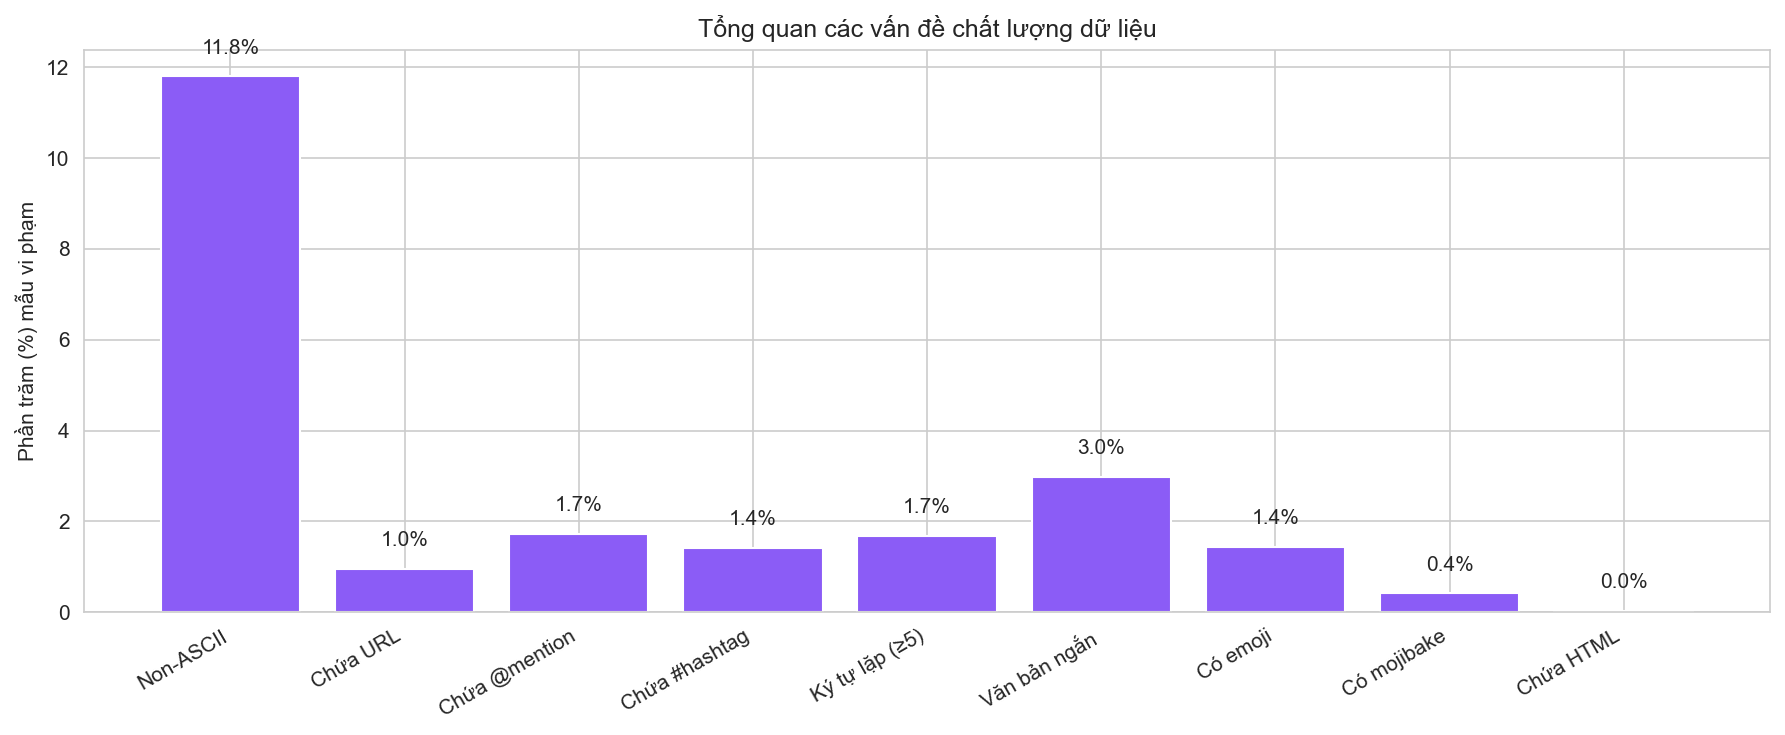

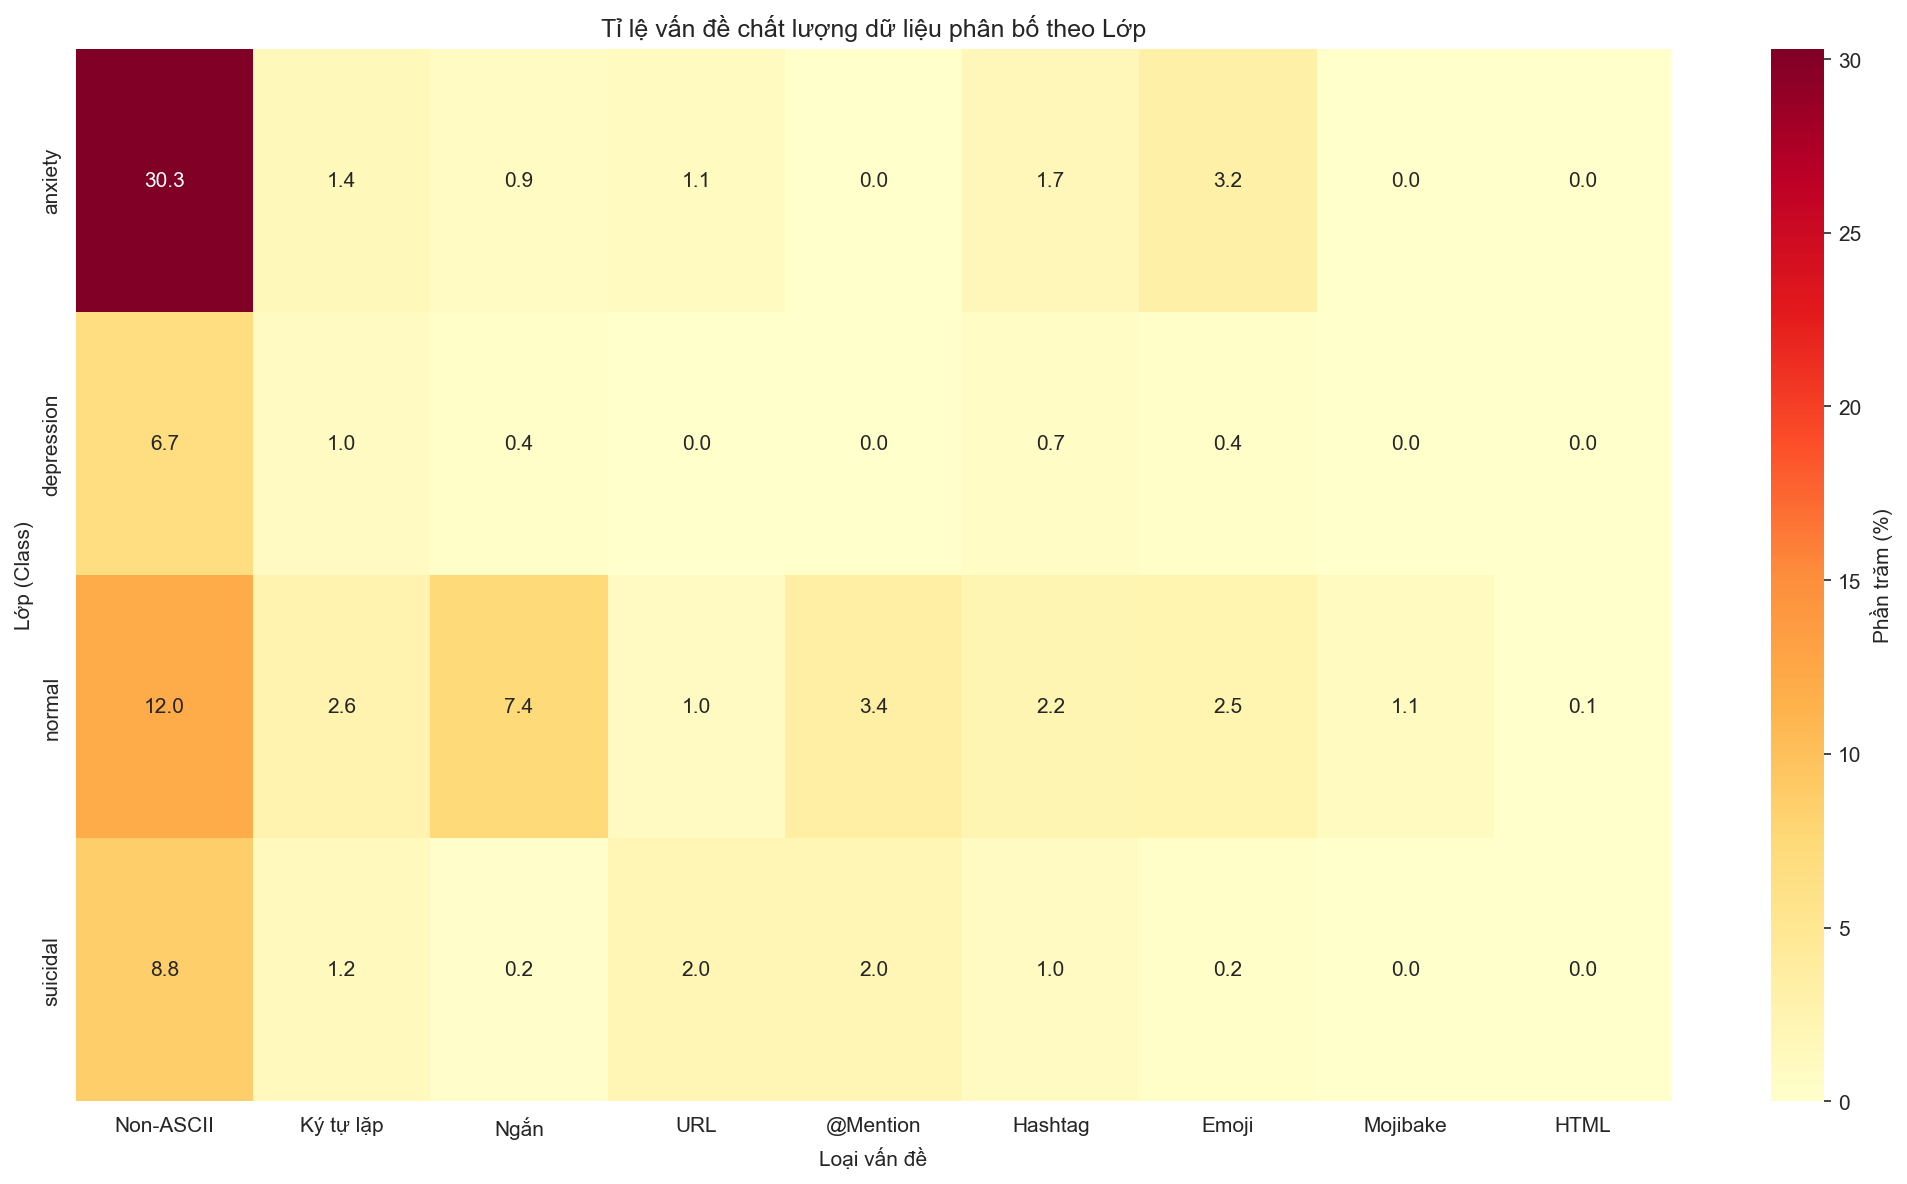


--- Ví dụ các mẫu văn bản chứa lỗi (Lấy ngẫu nhiên) ---

Chứa HTML (Tổng 7 mẫu):
  [1] I have replaced my bank card and everything else is canceled, but still haven't went to get a replacement license (another expense I don't really want to think of right now), so I am unable to get one of those free government phones. I am more than willing to repay you in any payment plan you come up with and I can put repayment to you as my second to top priority (I really need some new socks - they get priority, trust me on this, they took my socks and I'm on day 3). Anyway PM of you have any questions. I would be able to take PayPal, Cash App (I no longer have the card but can transfer to bank), a Kroger/Fry's egiftcard or an old T-Mobile phone / unlocked one if someone is local (around <location> ) and wants to meet up even after hearing about my socks. I do have a police report number if anyone needed to verify.
  [2] ZvM5U6tX '©â€ â â€ '‹â€ '© j9âƒ'pletquugð ppðŸ'¨â€ â â€ '‹â€ '¨g2uUnkð yðŸ'©â

In [39]:
data_quality_analysis(df_enriched)